# Datasets

In [11]:
# Import modules for data storage and basic computation
import pandas as pd
import numpy as np

# Import matplotlib module for figure representation
import matplotlib.pyplot as plt
import seaborn as sns
# Dictionary for controlling the font style of every figure to be created
title_font = {
    'family': 'Times New Roman',
    'weight': 'bold',
    'size': 18
}
axes_font = {
    'family': 'DejaVu Serif',
    'weight': 'bold',
    'size': 12
}
aux_font = {
    'family': 'Times New Roman',
    'color': 'black',
    'weight': 'normal',
    'size': 8
}

# Import fetch_ucirepo function for accessing UCI's ML benchmark datasets
from ucimlrepo import fetch_ucirepo

# Import sklearn functions for dataset preprocessing 
# (Categorical Features encoding and numerical features standarization)
# Simple imputation
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


# Import sklearn function for train- test splitting 
from sklearn.model_selection import train_test_split

# Define Random seed for reproductability
init_seed = 144

In [12]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
ord_categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent', fill_value = 'missing')),
    ('ordinalencoding', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value= -1))
])

card_categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent', fill_value = 'missing')),
    ('onehotencoding', OneHotEncoder(handle_unknown= 'ignore'))
])

## Benchmark Dataset 1: Heart Disease

The first dataset to be employed as a benchmark for the implementation of the $L_2$-TWSVM and $L_1$-TWSVM models (with feature selection per hyperplane) was provided from the University of California, Irvine (UCI) Machine Learning Repository. This dataset consists of 13 clinical attributes collected from a cohort of up to 303 patients.

The original target variable encodes the presence and severity of coronary artery disease, assigning values from 0 to 4, where 0 denotes absence of disease and values 1 through 4 correspond to different severity of diagnosed heart disease. For the purposes of this study, the problem is reformulated as a binary classification task by aggregating all non-zero categories into a single positive class, thereby distinguishing between patients with heart disease and those without.

This dataset is typically used as a benchmark to evaluate the performance of $SVM$, $L_2$-TWSVM and $L_1$-TWSVM models, with particular emphasis on their performance handling clinical binary classification problems.


In [13]:
# Benchmark Dataset name
dataset_name = 'HeartDisease' 

# Fetch the desired dataset from University of California, Irvine's Machine Learning Repository
heart_disease = fetch_ucirepo(id=45) 

# Store Benchmark dataset as pandas
X = heart_disease.data.features
Y = heart_disease.data.targets

# Dataset preprocessing
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
card_categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('cardinal', card_categorical_transformer, card_categorical_features)
])

Y = pd.DataFrame(np.where(Y == 0, 1, 0), columns = ['target'])


# Distribution of target classes (significant imbalance on target distribution)
print('Shape of dataset {} is {}'.format(dataset_name, X.shape))
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

Shape of dataset HeartDisease is (303, 13)
Distribution of target variable
target
1         54.125413
0         45.874587
Name: count, dtype: float64
Unique classes target    2
dtype: int64


## Benchmark Dataset 2: Breast Cancer

The second benchmark dataset was also obtained from the UCI Machine Learning Repository and consists of 569 observations of breast cancer patients from the state of Wisconsin. Each observation is described by 30 features derived from digitized images of fine needle aspirate (FNA) samples of breast masses.

The dataset exhibits a significant class imbalance in the target variable, which indicates whether a patient presents a benign breast mass (class 1) or a malignant one (class −1). Benign cases constitute the majority class, representing approximately 62.74% of the observations. Consequently, this dataset provides a first suitable setting for evaluating the performance and robustness of the TWSVM model under realistic imbalanced classification conditions.

In [38]:
# Dataset name
dataset_name = 'BreastCancer'

#Fetch the desired dataset as a dictionary
breast_cancer_dataset = fetch_ucirepo(id = 17)

# Store the desired data as pandas datasets
X = breast_cancer_dataset.data.features
Y = breast_cancer_dataset.data.targets

# Dataset preprocessing
numeric_features = X.select_dtypes(['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
])

Y = pd.DataFrame(np.where(Y == 'B', 1, 0), columns = ['target'])

# Distribution of target classes (significant imbalance on target distribution)
print('Shape of dataset {} is {}'.format(dataset_name, X.shape))
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

Shape of dataset BreastCancer is (569, 30)
Distribution of target variable
target
1         62.741652
0         37.258348
Name: count, dtype: float64
Unique classes target    2
dtype: int64


## Benchmark Dataset 3: Banknote Authentication

In [60]:
# Dataset name
dataset_name = 'BankNote'

# fetch dataset 
banknote_authentication = fetch_ucirepo(id=267) 
  
# data (as pandas dataframes) 
X = banknote_authentication.data.features 
Y = banknote_authentication.data.targets
Y = Y.rename(columns = {'class': 'target'})

# Dataset preprocessing
numeric_features = X.select_dtypes(['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
])

# Distribution of target classes (significant imbalance on target distribution)
print('Shape of dataset {} is {}'.format(dataset_name, X.shape))
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

Shape of dataset BankNote is (1372, 4)
Distribution of target variable
target
0         55.539359
1         44.460641
Name: count, dtype: float64
Unique classes target    2
dtype: int64


## Benchmark Dataset 4: Productivity Garment Employees

In [84]:
# dataset name
dataset_name = 'Productivity'

# fetch dataset
productivity_prediction_of_garment_employees = fetch_ucirepo(id=597) 

# datasets (as pandas)
X = productivity_prediction_of_garment_employees.data.features
X = X.drop(columns = ['date']) # multicolinear with day and quarter
Y = productivity_prediction_of_garment_employees.data.targets

# Dataset preprocessing
numeric_features = X.select_dtypes(['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(['object', 'category', 'string']).columns.tolist()
ord_categorical_features = [cat_feat for cat_feat in categorical_features if cat_feat not in ['department', 'day']]
card_categorical_features = ['department', 'day']
preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('ordinal', ord_categorical_transformer, ord_categorical_features),
    ('cardinal', card_categorical_transformer, card_categorical_features)
])

# Encode the Y target dataset, == 1 (actual_productivity > targeted_productivity) == positive class, 0
Y = pd.DataFrame(np.where(Y['actual_productivity'] >= 0.8, 1, 0), columns = ['target'])

# Distribution of target classes (significant imbalance on target distribution)
print('Shape of dataset {} is {}'.format(dataset_name, X.shape))
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

Shape of dataset Productivity is (1197, 13)
Distribution of target variable
target
0         52.715121
1         47.284879
Name: count, dtype: float64
Unique classes target    2
dtype: int64


## Benchmark Dataset 5: Synthetic Data

The last benchmark dataset serves as validation of the correct individual feature selection per hyperplane derived from the proposed L1-PTWSVM model. This synthetic dataset was generated using the make_classification function from the well- known sklearn.datasets module.

Following the scikit-learn module documentation, this function constructs a synthetic $N$ class classification problem by first generating a set of informative features that define class structure. Particularly, samples are drawn from Gaussian distributions centered at the vertices of a hypercube whose dimensionality matches the number of informative features specified. The remaining features are generated as random noise, without contributing predictive structure. Shuffling was disabled to preserve the earlier defined column order such that, the first features of the dataset correspond exactly to the underlying signal components.

In [26]:
from sklearn.datasets import make_classification

dataset_name = 'SyntheticData'

n_features = 10
n_significant = 2

X, Y = make_classification(n_samples = 600, n_features = n_features, n_informative= n_significant,
                           n_redundant = 0, n_repeated = 0, n_clusters_per_class = 1, flip_y = 0.03,
                           class_sep = .8, shuffle = False, random_state = init_seed)

features_names = np.array(['informative1', 'informative2'] + [f'noise{i+1}' for i in range(n_features - n_significant)])
X = pd.DataFrame(X, columns = features_names)
Y = pd.DataFrame(Y, columns = ['target'])

# Datasets preprocessing
numeric_features = X.select_dtypes(['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
])

print('Shape of dataset {} is {}'.format(dataset_name, X.shape))
print('Distribution of target variable')
print(100 * Y.value_counts() / len(Y))
print('Unique classes', Y.nunique())

Shape of dataset SyntheticData is (600, 10)
Distribution of target variable
target
0         50.5
1         49.5
Name: count, dtype: float64
Unique classes target    2
dtype: int64


# TWSVM implementations

## $L_2$-TWSVM

In [92]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from scipy.optimize import minimize


class PTWSVM:
    """
    Standard Soft-Margin L2 Twin Support Vector Machine (TWSVM)
    implemented with Pyomo.

    Parameters
    ----------
    c1 : float
        Penalty hyperparameter for the first optimization problem.
    c2 : float
        Penalty hyperparameter for the second optimization problem.
    """


    def __init__(self, c1: float = 1.0, c2: float = 1.0):

        # Hyperparameters
        self.c1, self.c2 = c1, c2

        # Hyperplane parameters
        self.w1_, self.b1_, self.w2_, self.b2_ = None, None, None, None

        # Initialize Platt scaling parameters, (a,b), later optimized within fit_probabilities()
        self.a, self.b = 0.0, 0.0

        # Initialize Polynomial logistic parameter
        self.c = 0.0

        # Initialize containers for optimum a, b, c parameters to be obtained at fit_probabilities()
        self.a_, self.b_, self.c_ = None, None, None
        

    def build1(self):

        model_1 = pyo.ConcreteModel('Standard Soft Margin L2-TWSVM 1')

        # model Sets
        model_1.N = pyo.RangeSet(0, self.A_ncols -1) # dim number
        model_1.I = pyo.RangeSet(0, self.A_nrows -1) # m1, num obs class 1
        model_1.J = pyo.RangeSet(0, self.B_nrows -1) # m2, num obs class 0

        # Variables
        model_1.w1 = pyo.Var(model_1.N, domain=pyo.Reals)
        model_1.b1 = pyo.Var(domain=pyo.Reals)
        model_1.xi2 = pyo.Var(model_1.J, domain=pyo.NonNegativeReals)

        # Objective
        def h1_objective(model):

            ls_term = sum(
                (
                    sum(
                        self.A[i, n] * model.w1[n]
                        for n in model.N
                    )
                    + model.b1
                ) ** 2
                for i in model.I
            )

            penalty_term = self.c1 * sum(
                model.xi2[j]
                for j in model.J
            )

            return 0.5 * ls_term + penalty_term

        model_1.obj = pyo.Objective(rule=h1_objective, sense=pyo.minimize)

        # Constraint
        def h1_constraint(model, j):

            return (
                -(
                    sum(
                        self.B[j, n] * model.w1[n]
                        for n in model.N
                    )
                    + model.b1
                )
                + model.xi2[j]
                >= 1
            )

        model_1.constraint = pyo.Constraint(model_1.J, rule=h1_constraint)

        self.model1 = model_1


    def build2(self):

        model_2 = pyo.ConcreteModel('Standard Soft Margin L2-TWSVM 2')

        # Sets
        model_2.N = pyo.RangeSet(0, self.A_ncols - 1)
        model_2.I = pyo.RangeSet(0, self.A_nrows - 1)
        model_2.J = pyo.RangeSet(0, self.B_nrows - 1)

        # Variables
        model_2.w2 = pyo.Var(model_2.N, domain=pyo.Reals)
        model_2.b2 = pyo.Var(domain=pyo.Reals)
        model_2.xi1 = pyo.Var(model_2.I, domain=pyo.NonNegativeReals)

        # Objective
        def h2_objective(model):

            ls_term = sum(
                (
                    sum(
                        self.B[j, n] * model.w2[n]
                        for n in model.N
                    )
                    + model.b2
                ) ** 2
                for j in model.J
            )

            penalty_term = self.c2 * sum(
                model.xi1[i]
                for i in model.I
            )

            return 0.5 * ls_term + penalty_term

        model_2.obj = pyo.Objective(rule=h2_objective, sense=pyo.minimize)

        # Constraint
        def h2_constraint(model, i):

            return (
                sum(
                    self.A[i, n] * model.w2[n]
                    for n in model.N
                )
                + model.b2
                + model.xi1[i]
                >= 1
            )

        model_2.constraint = pyo.Constraint(model_2.I, rule=h2_constraint)

        self.model2 = model_2


    def solve1(self, tee: bool = False):

        self.solver.solve(self.model1, tee=tee)

        m1 = self.model1

        self.w1_ = np.array([pyo.value(m1.w1[n]) for n in m1.N])

        self.b1_ = pyo.value(m1.b1)

        self.xi2_ = np.array([pyo.value(m1.xi2[j]) for j in m1.J])


    def solve2(self, tee: bool = False):

        self.solver.solve(self.model2, tee=tee)

        m2 = self.model2

        self.w2_ = np.array([pyo.value(m2.w2[n]) for n in m2.N])

        self.b2_ = pyo.value(m2.b2)

        self.xi1_ = np.array([pyo.value(m2.xi1[i]) for i in m2.I])


    def fit(self, X: np.ndarray, y: np.ndarray, solver: str = "gurobi", tee: bool = False):

        # Separate classes
        self.A = X[y == 1]
        self.B = X[y == 0]

        # Dataset dimensions
        self.A_nrows, self.A_ncols = self.A.shape
        self.B_nrows, self.B_ncols = self.B.shape

        # Clean previous model instances
        if hasattr(self, "model1"):
            del self.model1

        if hasattr(self, "model2"):
            del self.model2

        import gc
        gc.collect()

        # Create solver
        self.solver = pyo.SolverFactory(solver)

        if not self.solver.available():
            raise RuntimeError(
                f"Solver '{solver}' is not available."
            )

        # Solve first hyperplane
        self.build1()
        self.solve1(tee=tee)

        # Solve second hyperplane
        self.build2()
        self.solve2(tee=tee)

        return self
    

    def score_function(self, x: np.ndarray, alpha = 1):
        '''
        Compute the FTWSVM scores as defined in Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        Assume alpha = 1 allowing the later cross entropy minimization for obtaining the optimum sigmoid parameters a, b.
        '''
        # Retrieve the optimum parameters obtained solving the TWSVM opt problems
        w1, b1, w2, b2 = self.w1_, self.b1_, self.w2_, self.b2_
        # numeric stabilization
        eps = 1e-12

        # Weight vectors norms
        norm_w1 = max(np.linalg.norm(w1), eps)
        norm_w2 = max(np.linalg.norm(w2), eps)

        # euclidean distances to the separation hyperplanes derived from TWSVM
        d1 = (x @ w1 + b1) / norm_w1
        d2 = (x @ w2+ b2) / norm_w2

        # Normalized weight vectors
        w1_hat = w1 / norm_w1
        w2_hat = w2 / norm_w2

        # euclidean distances to the auxiliarly hyperplanes defined
        # the resulting D_plus, D_minus vectors have shape (n, ) measuring 
        # the euclidean dist to the each aux hyperplane (angle bisectors of the TWSVM hyperplanes) for each n observation
        D_plus = np.abs(d1 + d2) / max(np.linalg.norm(w1_hat + w2_hat), eps)
        D_minus = np.abs(d1 - d2) / max(np.linalg.norm(w1_hat - w2_hat), eps)

        # stack row- wise the two vectors (dist- aux is a (2, n) matrix)
        # each row corresponds to euclidean dists to each aux hyperplane (columns are obs)
        dists_aux = np.vstack([D_plus, D_minus])
        # compute min distance to auxiliarly hyperplanes for each obs (axis = 0 operates column- wise on the prev matrix)
        d = np.min(dists_aux, axis = 0)
        # max distance to auxiliarly hyperplanes
        D = np.maximum(np.max(dists_aux, axis = 0), eps)

        # Compute the relative euclidean distance to each separation hyperplane obtained by TWSVM
        # Equivalent to comparing the distance from each sample to each separation hyperplane and
        # assigning the sample to that class whose hyperplane is closer (lowest distance)
        ratio = (np.abs(x @ w1 + b1) / np.maximum(np.abs(x @ w2 + b2), eps)) * (norm_w2 / norm_w1)
        
        # Definition of the score function as in 
        # Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        quant = d * (d / D) ** alpha
        scores = np.zeros(quant.shape)

        scores[ratio < 1] = quant[ratio < 1] # positive scores for positve class obs
        scores[ratio > 1] = - quant[ratio > 1] # negative scores for negative class obs
        # scores[ratio == 1] = 0 by definition of scores obj (zero score for those obs lying at equidistant from either class hyperplane)

        return scores


    def fit_probabilities(self, x: np.ndarray, y: np.ndarray, method: str):
        '''
        Optimize the logistic parameters via cross- entropy minimization
        The cross entropy has been proved convex (positive definite Hessian) hence, Newton methods can applied for solving the minimization
        without the risk of finding local minima. Scipy.optimize.minimize function is used with the BFGS algorithm.
        This function accepts two possible methods denoted by the strings 'platt' and 'polynomial'.
        The 'platt' method fits a sigmoid function of the form 1 / (1 + exp(a*f(x) + b) into the obtained scores for obtaining the predicted
        posterior probabilities for the positive class. The optimization of the parameters a, b  is accomplished by minimizing the cross entropy as proposed by Platt's(2000).
        The 'polynomial' method fits a polynomial logistic function of the form 1 / (1 + exp(a*f(x)**2 + b*f(x) + c) into the scores generated by TWSVM for
        defining the posterior probabilities of the positive class. Again optimization is done by cross entropy minimization via Newton's methods.
        '''

        # Store the selected methodology for computing parametric probabilities within the instance (self)
        self.method = method

        # Define the scores
        f = self.score_function(x)

        # Define target probabilities with laplace smoothing
        t = np.where(y == 1,
                    (self.A_nrows + 1) / (self.A_nrows + 2),
                    1 / (self.B_nrows + 2))
        
        # Compute the cross entropy
        def cross_entropy(theta):
            '''
            Cross entropy function is defined by two parameters a, b
            These parameters are passed as part of a tupple named theta.
            '''

            # Compute predicted posterior probabilities
            if method == 'platt':
                a, b = theta
                z = np.clip(a*f + b, -30, 30)
                p = 1 / (1 + np.exp(z))
            elif method == 'polynomial':
                a, b, c = theta
                z = np.clip(a * f**2 + b*f + c, -30, 30)
                p = 1 / (1 + np.exp(z))

            # Bound predicted posterior probabilities for numerical stability
            eps = 1e-12
            p = np.clip(p, eps, 1-eps)

            # Return the cross entropy (negative log-likelihood)
            return -np.sum(t * np.log(p) + (1-t) * np.log(1 - p))
        
        # Apply scipy.optimize.minimize function for optimizing the defined cross_entropy
        # Notice the minimize function uses the initializing values defined in the constructor method
        if method == 'platt':
            result = minimize(cross_entropy, x0= [self.a, self.b], method = 'BFGS')
            self.a_, self.b_ = result.x
        elif method == 'polynomial':
            result = minimize(cross_entropy, [self.a, self.b, self.c], method = 'BFGS')
            self.a_, self.b_, self.c_ = result.x

        return self

    def predict_proba(self, x: np.ndarray):
        '''
        Predict the probability of an observation belonging to the positive class (class 1)
        Uses the opt parameters a, b obtained with fit_probabilities() to fit a sigmoid on new scores
        '''
        
        # This function needs fit_probabilities to be called first,
        if self.method == 'platt' and (self.a_ is None or self.b_ is None):
            raise Exception('Call fit_probabilities() with method = "platt" before')
        if self.method == 'polynomial' and (self.a_ is None or self.b_ is None or self.c_ is None):
            raise Exception('Call fit_probabilities() with method = "polynomial" before')

        # Compute scores
        f = self.score_function(x)
        # Compute predicted posterior probabilities
        if self.method == 'platt':
            p = 1 / (1 + np.exp(self.a_ * f + self.b_))
        elif self.method == 'polynomial':
            p = 1 / (1 + np.exp(self.a_*f**2 + self.b_*f + self.c_))

        return p

    
    def predict(self, x: np.ndarray):
        scores = self.score_function(x)

        predictions = np.ones(x.shape[0])
        predictions[scores < 0] = 0

        return predictions

# Boostrapping experiment on PTWSVM

In [93]:
from sklearn.utils import resample
from sklearn.metrics import balanced_accuracy_score
from itertools import product
from joblib import Parallel, delayed


#----------------------------------------------------------------------
# Parameters definition
#----------------------------------------------------------------------
B = 50 # Number of boostrap samples
method = 'platt' # Scaling method used in the probabilistic model (fit the scores to generate probabilities)
index = X.index.to_numpy() # Index of the dataset X as a numpy (later identification of OOB obs)


#----------------------------------------------------------------------
# Define Grid search
#----------------------------------------------------------------------
grid = {
    'c1': np.logspace(-8,-1,8, base = 2),
    'c2': np.logspace(-8,-1,8, base = 2)
}

#----------------------------------------------------------------------
# Dictionaries storing bootstrap experiment results for each (theta, b)
#----------------------------------------------------------------------
# Dictionaries containing for each theta a 1D numpy array (B,)
# each entry in the numpy array corresponds to the accuracy (mse) for a (theta, b)
accuracies = {}
mse = {} # MSE = BS (binary classification)

# Dictionary with theta as keys. For each theta it comprises a dictionary with an obs index
# as key. For each theta it records the predicted probabilities given for each observation
predicted_probs = {}


#----------------------------------------------------------------------
# Function defining a single bootstrap iteration
#----------------------------------------------------------------------
def run_bootstrap(c1, c2, b,
                  X, Y, preprocessor, index, method):

    # Creates a new instance of the ptwsvm class with the given theta
    ptwsvm =PTWSVM(c1, c2)

    # Generate the bootstrap replicate (by sampling with replacement the entire dataset)
    idx_b = resample(index, replace=True, random_state = init_seed + b) # Define the indexes of the obs in the bootstrap sample
    # Define the bootstrap sample
    X_Tb = X.iloc[idx_b, :] 
    Y_Tb = Y.iloc[idx_b].values.ravel()
    # Define the indexes of the OOB observations
    idx_oob = np.setdiff1d(index, idx_b)
    # OOB observations
    X_Vb = X.iloc[idx_oob, :]
    Y_Vb = Y.iloc[idx_oob].values.ravel()

    # Fit preprocessing using the bootstrap sample and apply it on the OOB observations
    X_Tb = preprocessor.fit_transform(X_Tb)
    X_Vb = preprocessor.transform(X_Vb)

    # Fit thePFSTWSVM model using the T_b bootstrap sample
    ptwsvm.fit(X_Tb, Y_Tb)
    ptwsvm.fit_probabilities(X_Tb, Y_Tb, method=method)

    # Predicted posterior probabilities on the OOB obs
    probs =ptwsvm.predict_proba(X_Vb)

    # Compute the balanced accuracy 
    acc = balanced_accuracy_score(Y_Vb,ptwsvm.predict(X_Vb))
    # Compute the BS 
    mse = np.mean((probs - Y_Vb) ** 2)

    # For each bootstrap sample the results of the bootstrap experiment
    # are returned in a dictionary
    return {
        "acc": acc,
        "mse": mse,
        "idx_oob": idx_oob,
        "probs": probs
    }


#----------------------------------------------------------------------
# Bootstrap experiment (parallelizing the B=50 bootstrap samples for each theta)
#----------------------------------------------------------------------
count = 0

for c1, c2 in product(*grid.values()): # Iterate across theta hyperparameter configurations

    # For each theta assign a 1D numpy array (B,) containing the accuracy scored at each bootstrap sample
    accuracies[(c1, c2)] = np.empty(B, dtype = float)
    mse[(c1, c2)] = np.empty(B, dtype = float)

    # For each theta assign a dictionary to contain the predicted probs generated for each obs
    predicted_probs[(c1, c2)] = {obs: [] for obs in index}

    # results is a list of dictionaries
    # each dictionary contains the results obtained for each bootstrap sample
    results = Parallel( # Parallelize the given list of tasks returned by delayed
        n_jobs=-1,
        backend="loky"
    )(
        delayed(run_bootstrap)( 
            c1,c2,b,
            X,Y,preprocessor,index,method
        )
        for b in range(B) # wraps the run_bootstrap function with an iterator, it creates a list of tasks to be solved
    )

    for b, r in enumerate(results):
        # Store the results obtained across the B=50 bootstrap replicates for each theta 
        accuracies[(c1,c2)][b] = r["acc"]
        mse[(c1,c2)][b] = r["mse"]

        for idx, p in zip(r["idx_oob"], r["probs"]):
            predicted_probs[(c1,c2)][idx].append(p)

    count += 1
    print(f'Hyperparameter combinations {count}/{len(list(grid.values())[0]) ** len(grid)}')

Hyperparameter combinations 1/64
Hyperparameter combinations 2/64
Hyperparameter combinations 3/64
Hyperparameter combinations 4/64
Hyperparameter combinations 5/64
Hyperparameter combinations 6/64
Hyperparameter combinations 7/64
Hyperparameter combinations 8/64
Hyperparameter combinations 9/64
Hyperparameter combinations 10/64
Hyperparameter combinations 11/64
Hyperparameter combinations 12/64
Hyperparameter combinations 13/64
Hyperparameter combinations 14/64
Hyperparameter combinations 15/64
Hyperparameter combinations 16/64
Hyperparameter combinations 17/64
Hyperparameter combinations 18/64
Hyperparameter combinations 19/64
Hyperparameter combinations 20/64
Hyperparameter combinations 21/64
Hyperparameter combinations 22/64
Hyperparameter combinations 23/64
Hyperparameter combinations 24/64
Hyperparameter combinations 25/64
Hyperparameter combinations 26/64
Hyperparameter combinations 27/64
Hyperparameter combinations 28/64
Hyperparameter combinations 29/64
Hyperparameter combinat

In [94]:
# Compute avg accuracies across boostrap samples for each theta
avg_accuracies = {
    theta: np.mean(accs)
    for theta, accs in accuracies.items()
}

# Best hyperparameters combination (theta*)
max_theta = max(avg_accuracies, key = avg_accuracies.get)
max_theta_mean = avg_accuracies[max_theta] # mean(acc_{theta*})
max_theta_std = np.std(accuracies[max_theta], ddof = 1) # std(acc_{theta*}) dividing by N-1 (small samples)

# Epsilon = boostrap variability of PTWSVM with theta*
epsilon = max_theta_std * 0.5

# Optimal set 
# (hyperparameters combinations with acc within 1 std of acc_{theta*})
top_theta = {
    theta for theta, avg_acc in avg_accuracies.items()
    if avg_acc >= max_theta_mean - epsilon
}
top_theta = sorted(top_theta, key = avg_accuracies.get, reverse = True)

print(f'PTWSVM Results using the dataset {dataset_name}')
print(f'The best hyperparameter combination was{max_theta}')
print(f'Average accuracy across B = {B} bootstrap samples of the best hyperparameter combination was, {max_theta_mean}')
print(f'Standard deviation of the accuracy of the best hyperparameter combination, {max_theta_std}')


# List enclosing all the possible hyperparameters combinations
all_theta = list(product(*grid.values()))

# Compute avg MSE (Brier Score) across boostrap samples for each theta
avg_mse = {
    theta: np.mean(mses)
    for theta, mses in mse.items()
}

# Standarized brier score for each theta hyperparameter combination
mse_weights = np.array([
    1 - avg_mse[theta]
    for theta in all_theta
])
mse_weights_std = mse_weights / np.sum(mse_weights)

# Matrix containing the avg predicted prob across boostrap samples
# for each instance (row) given each hyperparameter combination (column)
boost_avg_probs = np.empty((len(X), len(accuracies)), )
for t, theta in enumerate(avg_accuracies.keys()):
    for obs, probs in predicted_probs[theta].items():
        boost_avg_probs[obs, t] = np.mean(probs)

# Weighted average of the predicted probabilities for each instance
avg_predicted_probs = boost_avg_probs @ mse_weights_std

max_theta_avg_mse = avg_mse[max_theta]
max_theta_std_mse = np.std(mse[max_theta], ddof = 1)

print(f'PTWSVM Results using the dataset {dataset_name}')
print(f'The best hyperparameter combination was{max_theta}')
print(f'Average mse across B = {B} bootstrap samples of the best hyperparameter combination was, {max_theta_avg_mse}')
print(f'Standard deviation of the accuracy of the best hyperparameter combination, {max_theta_std_mse}')

PTWSVM Results using the dataset Productivity
The best hyperparameter combination was(np.float64(0.125), np.float64(0.125))
Average accuracy across B = 50 bootstrap samples of the best hyperparameter combination was, 0.5149802890294682
Standard deviation of the accuracy of the best hyperparameter combination, 0.004680942233709011
PTWSVM Results using the dataset Productivity
The best hyperparameter combination was(np.float64(0.125), np.float64(0.125))
Average mse across B = 50 bootstrap samples of the best hyperparameter combination was, 0.20736116493941922
Standard deviation of the accuracy of the best hyperparameter combination, 0.009480977024531064


# Boostrapping experiment on standard linear SVM (Scikit-learn)

In [88]:
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import balanced_accuracy_score
from itertools import product
from joblib import Parallel, delayed


#----------------------------------------------------------------------
# Parameters definition
#----------------------------------------------------------------------
B = 50 # Number of boostrap samples
method = 'platt' # Scaling method used in the probabilistic model (fit the scores to generate probabilities)
index = X.index.to_numpy() # Index of the dataset X as a numpy (later identification of OOB obs)


#----------------------------------------------------------------------
# Define Grid search
#----------------------------------------------------------------------
grid = {
    'c': np.logspace(-8,7,16, base = 2)
}

#----------------------------------------------------------------------
# Dictionaries storing bootstrap experiment results for each (theta, b)
#----------------------------------------------------------------------
# Dictionaries containing for each theta a 1D numpy array (B,)
# each entry in the numpy array corresponds to the accuracy (mse) for a (theta, b)
accuracies = {}
mse = {} # MSE = BS (binary classification)

# Dictionary with theta as keys. For each theta it comprises a dictionary with an obs index
# as key. For each theta it records the predicted probabilities given for each observation
predicted_probs = {}


#----------------------------------------------------------------------
# Function defining a single bootstrap iteration
#----------------------------------------------------------------------
def run_bootstrap(c, b,
                  X, Y, preprocessor, index, method):

    # Creates a new instance of the SVM Classifier class with the given theta
    svm = SVC(kernel = 'linear', probability = True, C = c, random_state=init_seed)

    # Generate the bootstrap replicate (by sampling with replacement the entire dataset)
    idx_b = resample(index, replace=True, random_state = init_seed + b) # Define the indexes of the obs in the bootstrap sample (reproducible)
    # Define the bootstrap sample
    X_Tb = X.iloc[idx_b, :] 
    Y_Tb = Y.iloc[idx_b].values.ravel()
    # Define the indexes of the OOB observations
    idx_oob = np.setdiff1d(index, idx_b)
    # OOB observations
    X_Vb = X.iloc[idx_oob, :]
    Y_Vb = Y.iloc[idx_oob].values.ravel()

    # Fit preprocessing using the bootstrap sample and apply it on the OOB observations
    X_Tb = preprocessor.fit_transform(X_Tb)
    X_Vb = preprocessor.transform(X_Vb)

    # Fit thePFSTWSVM model using the T_b bootstrap sample
    svm.fit(X_Tb, Y_Tb)

    # Predicted posterior probabilities on the OOB obs
    probs =svm.predict_proba(X_Vb)[:, 1]

    # Compute the balanced accuracy 
    acc = balanced_accuracy_score(Y_Vb,svm.predict(X_Vb))
    # Compute the BS 
    mse = np.mean((probs - Y_Vb) ** 2)

    # For each bootstrap sample the results of the bootstrap experiment
    # are returned in a dictionary
    return {
        "acc": acc,
        "mse": mse,
        "idx_oob": idx_oob,
        "probs": probs
    }


#----------------------------------------------------------------------
# Bootstrap experiment (parallelizing the B=50 bootstrap samples for each theta)
#----------------------------------------------------------------------
count = 0

for c in grid['c']: # Iterate across theta hyperparameter configurations

    # For each theta assign a 1D numpy array (B,) containing the accuracy scored at each bootstrap sample
    accuracies[c] = np.empty(B, dtype = float)
    mse[c] = np.empty(B, dtype = float)

    # For each theta assign a dictionary to contain the predicted probs generated for each obs
    predicted_probs[c] = {obs: [] for obs in index}

    # results is a list of dictionaries
    # each dictionary contains the results obtained for each bootstrap sample
    results = Parallel( # Parallelize the given list of tasks returned by delayed
        n_jobs=-1,
        backend="loky"
    )(
        delayed(run_bootstrap)( 
            c,b,
            X,Y,preprocessor,index,method
        )
        for b in range(B) # wraps the run_bootstrap function with an iterator, it creates a list of tasks to be solved
    )

    for b, r in enumerate(results):
        # Store the results obtained across the B=50 bootstrap replicates for each theta 
        accuracies[c][b] = r["acc"]
        mse[c][b] = r["mse"]

        for idx, p in zip(r["idx_oob"], r["probs"]):
            predicted_probs[c][idx].append(p)

    count += 1
    print(f'Hyperparameter combinations {count}/{len(list(grid.values())[0]) ** len(grid)}')

Hyperparameter combinations 1/16
Hyperparameter combinations 2/16
Hyperparameter combinations 3/16
Hyperparameter combinations 4/16
Hyperparameter combinations 5/16
Hyperparameter combinations 6/16
Hyperparameter combinations 7/16
Hyperparameter combinations 8/16
Hyperparameter combinations 9/16
Hyperparameter combinations 10/16
Hyperparameter combinations 11/16
Hyperparameter combinations 12/16
Hyperparameter combinations 13/16
Hyperparameter combinations 14/16
Hyperparameter combinations 15/16
Hyperparameter combinations 16/16


In [89]:
# Compute avg accuracies across boostrap samples for each theta
avg_accuracies = {
    theta: np.mean(accs)
    for theta, accs in accuracies.items()
}

# Best hyperparameters combination (theta*)
max_theta = max(avg_accuracies, key = avg_accuracies.get)
max_theta_mean = avg_accuracies[max_theta] # mean(acc_{theta*})
max_theta_std = np.std(accuracies[max_theta], ddof = 1) # std(acc_{theta*}) dividing by N-1 (small samples)

# Epsilon = boostrap variability of PTWSVM with theta*
epsilon = max_theta_std * 0.5

# Optimal set 
# (hyperparameters combinations with acc within 1 std of acc_{theta*})
top_theta = {
    theta for theta, avg_acc in avg_accuracies.items()
    if avg_acc >= max_theta_mean - epsilon
}
top_theta = sorted(top_theta, key = avg_accuracies.get, reverse = True)

print(f'Linear SVM Results using the dataset {dataset_name}')
print(f'The best hyperparameter combination was{max_theta}')
print(f'Average accuracy across B = {B} bootstrap samples of the best hyperparameter combination was, {max_theta_mean}')
print(f'Standard deviation of the accuracy of the best hyperparameter combination, {max_theta_std}')


# List enclosing all the possible hyperparameters combinations
all_theta = list(grid['c'])

# Compute avg MSE (Brier Score) across boostrap samples for each theta
avg_mse = {
    theta: np.mean(mses)
    for theta, mses in mse.items()
}

# Standarized brier score for each theta hyperparameter combination
mse_weights = np.array([
    1 - avg_mse[theta]
    for theta in all_theta
])
mse_weights_std = mse_weights / np.sum(mse_weights)

# Matrix containing the avg predicted prob across boostrap samples
# for each instance (row) given each hyperparameter combination (column)
boost_avg_probs = np.empty((len(X), len(accuracies)), )
for t, theta in enumerate(avg_accuracies.keys()):
    for obs, probs in predicted_probs[theta].items():
        boost_avg_probs[obs, t] = np.mean(probs)

# Weighted average of the predicted probabilities for each instance
avg_predicted_probs = boost_avg_probs @ mse_weights_std

max_theta_avg_mse = avg_mse[max_theta]
max_theta_std_mse = np.std(mse[max_theta], ddof = 1)

print(f'Linear SVM Results using the dataset {dataset_name}')
print(f'The best hyperparameter combination was{max_theta}')
print(f'Average mse across B = {B} bootstrap samples of the best hyperparameter combination was, {max_theta_avg_mse}')
print(f'Standard deviation of the accuracy of the best hyperparameter combination, {max_theta_std_mse}')

Linear SVM Results using the dataset Productivity
The best hyperparameter combination was32.0
Average accuracy across B = 50 bootstrap samples of the best hyperparameter combination was, 0.7482267725838265
Standard deviation of the accuracy of the best hyperparameter combination, 0.01681731759691697
Linear SVM Results using the dataset Productivity
The best hyperparameter combination was32.0
Average mse across B = 50 bootstrap samples of the best hyperparameter combination was, 0.18680465152404963
Standard deviation of the accuracy of the best hyperparameter combination, 0.007053300795578346


## TWSVM with Embedded Feature Selection ($L_1$-TWSVM)

L1-TWSVM introduces $L_1$ norm of the regularization terms of each hyperplane namely, $Aw_1 + e_1b_1$ and $Bw_2 + e_2b_2$, as well as the $L_1$-norm of the weights vectors $w_i$, $i=1, 2$ as in Bai, L. Wang, Z. Shao Y.H & Deng, N. Y (2014)

$$
\begin{align*}
&\min_{w_1, b_1, \xi_2}\;\; \|w_1\|_1 + c_1\|Aw_1+e_1b_1\|_1 + c_3\|\xi_1\|_1 \\
&\text{s.t} \\
&\begin{cases}
& -(Bw_1+e_2b_1) \geq e_2 - \xi_1 \\
& \xi_1 \geq 0
\end{cases} \\
&\text{and} \\[2ex]
&\min_{w_2, b_2, \xi_1}\;\;\|w_2\|_1 + c_2\|Bw_2+e_2b_2\|_1 + c_4\|\xi_2\|_1 \\
&\text{s.t} \\
&\begin{cases}
& (Aw_2+e_1b_2) \geq e_1 - \xi_2 \\
& \xi_2 \geq 0
\end{cases}
\end{align*}
$$

The earlier representation of the $L_1$-TWSVM compose a Nondifferentiable Programming Problem due to the presence on the objective function of non linear term as, $\|w_1\|_1 = \sum_{n=1}^N|w_n^{(1)}|$ and $\|Aw_1+e_1b_1\|_1 = \sum_{i=1}^{m_1}|\sum_{n=1}^Na_{i,n}w_n^{(1)} + b_1|$ in the definition of the first TWSVM hyperplane.

This problem can be transformed into a Differentiable Linear Programming Problem (DLPP) to be solved by the version of the Simplex algorithm implemented by the Gurobi optimizer just by introducing the following auxiliar variables, $w_i = p_i - q_i$ as well as, $Aw_1 + e_ib_1 = s_1 - t_i$ and $Bw_2 + e_2b_2 = s_2 - t_2$.

The auxiliary variables introduce a positive-negative decomposition of the weight vectors and residual terms, where each variable is expressed as the difference of two nonnegative variables. This allows their absolute values to be represented as the sum of these components, thereby enabling a linear formulation of the $L_1$-TWSVM.

\begin{align*}
& \min_{p_1,q_1,s_1,t_1,b_1,\xi_2} e_1^T(p_1 + q_1) + c_1e_1^T(s_1 + t_1) + c_3e_1^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& A(p_1 - q_1) + e_1b_1 = s_1 - t_1 \\
& B(p_1 - q_1) + e_2b_1 \leq -e_2 + \xi_1 \\
& p_1, q_1, s_1, t_1, \xi_1 \geq 0
\end{cases} \\
& \text{and} \\
& \min_{p_2,q_2,s_2,t_2,b_2,\xi_1} e_2^T(p_2 + q_2) + c_2e_2^T(s_2 + t_2) + c_4e_2^T\xi_2 \\
& \text{s.t} \\
& \begin{cases}
& B(p_2 - q_2) + e_2b_2 = s_2 - t_2 \\
& A(p_2 - q_2) + e_1b_2 \geq e_1 - \xi_2 \\
& p_2,q_2,s_2,t_2,\xi_2
\end{cases}
\end{align*}

Noticing, $s_1 = A(p_1 - q_1) + e_1b_1 + t_1$ and $s_2 = B(p_2 - q_2) + e_2b_2 + t_2$ the final DLPPs to be solved by Gurobi's Simplex algorithm implementation are defined,

$$
\begin{align*}
& \min_{p_1,q_1,t_1,b_1,\xi_2} e_1^T(p_1+q_1) + c_1e_1^T(A(p_1 -q_1) + 2t_1) + c_1m_1b_1 + c_3e_1^T\xi_1 \\
& \text{s.t} \\
& \begin{cases}
& A(p_1 - q_1) + e_1b_1 + t_1 \geq 0 \\
& B(p_1-q_1) + e_2b_1 \leq -e_2 + \xi_1 \\
& p_1, q_1, t_1, \xi_1 \geq 0 
\end{cases} \\
& \text{and} \\
& \min_{p_2,q_2,t_2,b_2,\xi_1} e^T(p_2 + q_2) + c_2e^T(B(p_2 - q_2) + 2t_2) + c_2m_2b_2 + c_4e_2^T\xi_2 \\
& \text{s.t} \\
& \begin{cases}
& B(p_2-q_2) + e_2b_2 + t_2 \geq 0 \\
& A(p_2-q_2) + e_1b_2 \geq e_1 - \xi_2 \\
& p_2,q_2,t_2,\xi_2 \geq 0
\end{cases}
\end{align*}
$$

where $m_1 = e_1^Te_1$ and $m_2 = e_2^Te_2$ denote the total training observations of each class respectively.

**Post Hoc Feature Selection**

$L_1$-TWSVM directly compose an individual feature selection method per hyperplane by imposing sparsity on the weight vectors corresponding to each hyperplane such that the less relevant features see its weights be collapsed to zero. Each hyperplane selects relevant features by discarding those which weights are zero. Namely, $n_1$ would represent the set of significant features selected by solving the first $L_1$-TWSVM hyperplane and similarly $n_2$ for the second $L_1$-TWSVM hyperplane. 

## Probability model for FTWSVM (TWSVM with Feature Selection)

Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012) propose a continuous scoring function to approximate the posterior probability of a sample $\tilde{x}$ belonging to a class. This score is constructed based on the geometric position of the sample $\tilde{x}$ relative to two auxiliary hyperplanes,
$$
\begin{cases}
\frac{w_1^T\tilde{x} + b_1}{\|w_1\|} - \frac{w_2^T\tilde{x} + b_2}{\|w_2\|} = 0 \\
\frac{w_1^T\tilde{x} + b_1}{\|w_1\|} + \frac{w_2^T\tilde{x} + b_2}{\|w_2\|} = 0
\end{cases}
$$

Defined the distances from the sample to those auxiliarly hyperplanes, $D_+(x) = \frac{|d_1(x) + d_2(x)|}{\|\frac{w_1}{\|w_1\|} + \frac{w_2}{\|w_2\|}\|}$ and $D_-(x) = \frac{|d_1(x) - d_2(x)|}{\|\frac{w_1}{\|w_1\|} - \frac{w_2}{\|w_2\|}\|}$, thus it can be identified the maximum and minimum distance from the sample to either auxiliarly hyperplane, $d(x)$ and $D(x)$ such that the relevant quantities $d(x)$ and $\frac{d(x)}{D(x)}$ can be defined.

It is observed that the higher either $d(x)$ or $\frac{d(x)}{D(x)}$ are the more likely a sample belongs to the positive class. Therefore the score function is defined as,

$$
f(x) = \begin{cases} d(x)(\frac{d(x)}{D(x)})^{\alpha} &\frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} < \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|}  \\
0 & \frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} = \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|} \\
-d(x)(\frac{d(x)}{D(x)})^{\alpha} & \frac{|w_1^T\tilde{x} + b_1|}{\|w_1\|} > \frac{|w_2^T\tilde{x} + b_2|}{\|w_2\|}
\end{cases}
$$

**Platt scaling probability model**

The probability model can be constructed by using a sigmoid to transform the results yielded by the earlier function into probabilities,

$$
P(y= +1| f(x)) = \frac{1}{1 + e^{af(x) + b}} \\
p(y = -1| f(x)) = 1 - P(y = +1 | f(x))
$$

Setting the weight parameter $\alpha = 1$, the parameters $a, b$ for the sigmoid can be obtained by minimizing the cross- entropy between predicted probabilities $p_i$ and  target probabilities $t_i$ in the following convex optimization problem,

$$
\begin{align*}
\min_{a,b} \;& - \sum_{i=1}^m \Big( t_i \log(p_i) + (1-t_i) \log(1-p_i) \Big) \\
\text{s.t.} \;& p_i = P(y = +1 \mid f(x_i)), \\
&t_i = 
\begin{cases} 
\dfrac{m_1 + 1}{m_1 + 2}, & \text{if } y_i = +1,\\[1em]
\dfrac{1}{m_2 + 2}, & \text{if } y_i = -1.
\end{cases}
\end{align*}
$$

Notice, the target probabilities $t_i$ are defined by Laplace smoothing.

**Polynomial Logistic, probability model**

Instead of the sigmoid proposed by Platt (2000), a polyinomial logistic function can be implemented for converting the confidence scores yielded by the previous function $f(x)$ into probabilities.
$$
P(y = 1| f(x)) = \frac{1}{1 + e^{af(x)^2 + bf(x) + c}}
$$

In [68]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from scipy.optimize import minimize

class PFSTWSVM():
    '''
    The proposed classifier combines the probabilistic Twin Support Vector Machine (PTWSVM) 
    introduced by Shao et al. (2012) with the sparse L1-TWSVM formulation proposed by Bai et al. (2014).
    The model estimates two non-parallel proximal hyperplanes by solving two differentiable linear 
    programming problems formulated in Pyomo and solved using the Gurobi Optimizer.
    
    The L1 regularization terms promote sparse weight vectors, which are subsequently exploited 
    for feature selection. A post-hoc ranking procedure is implemented by aggregating the absolute 
    values of the weights associated with each feature across both hyperplanes. Features whose 
    aggregated importance exceeds a predefined threshold are retained.
    
    Classification is performed through the score function proposed by Shao et al. (2012), which 
    generates a continuous confidence score based on the relative position of a sample with 
    respect to the proximal and auxiliary angle-bisector hyperplanes. Hard class labels are obtained 
    according to the sign of the score.
    
    Posterior probabilities are estimated through a calibration stage. 
    Two alternatives are provided: (i) Platt scaling, corresponding to a logistic transformation 
    of the score function, and (ii) a polynomial logistic model. The calibration parameters 
    are estimated by minimizing the cross-entropy loss using the BFGS quasi-Newton algorithm.
    '''

    def __init__(self, c11: float, c21: float, c12: float, c22:float):

        # Store input TWSVM parameters within class instances (self)
        self.c11, self.c21, self.c12, self.c22 = c11, c21, c12, c22

        # Initialize containers for optimum TWSVM parameters w1_, b1_, w2_, b2_
        self.w1_, self.b1_, self.w2_, self.b2_ = None, None, None, None

        # Initialize Platt scaling parameters, (a,b), later optimized within fit_probabilities()
        self.a, self.b = 0.0, 0.0
        # Initialize Polynomial logistic parameter
        self.c = 0.0
        # Initialize containers for optimum a, b, c parameters to be obtained at fit_probabilities()
        self.a_, self.b_, self.c_ = None, None, None
    

    # L_1-TWSVM 1 Construction
    def build1(self):
        # Define pyomo model object
        model1 = pyo.ConcreteModel('FTWSVM_1')

        # model Sets
        model1.N = pyo.RangeSet(0, self.A_ncols -1) # dim number
        model1.I = pyo.RangeSet(0, self.A_nrows -1) # m1, num obs class 1
        model1.J = pyo.RangeSet(0, self.B_nrows -1) # m2, num obs class 0

        # model variables
        model1.b1 = pyo.Var(domain = pyo.Reals)
        model1.xi2 = pyo.Var(model1.J, domain = pyo.NonNegativeReals)
        # Aux vars for computing the abs value of w_1 as |w_1| = p1 + q1
        model1.p1 = pyo.Var(model1.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_1 = p1 - q1)
        model1.q1 = pyo.Var(model1.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_1 = p1 - q1)
        # Aux vars for computing the abs value of Aw_1 + e_1b_1 as |Aw_1 + e_1b_1| = s1 + t1
        model1.t1 = pyo.Var(model1.I, domain = pyo.NonNegativeReals) # Aux var t1 (Aw_1 + e_1b_1 = s_1 - t_1)

        # TWSVM 1 Objective function
        def h1_objective(model1):
            fs_term = sum((model1.p1[n] + model1.q1[n]) for n in model1.N)
            ls_term1 = sum(
                sum(self.A[i,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + 2 * model1.t1[i]
                for i in model1.I
            )
            ls_term2 = len(model1.I) * model1.b1
            penalty_term = sum(model1.xi2[j] for j in model1.J)
            return fs_term + self.c11 * ls_term1 + self.c11 * ls_term2 + self.c12 * penalty_term

        model1.obj = pyo.Objective(rule = h1_objective, sense = pyo.minimize)

        # TWSVM 1 s1 aux variable definition constraint
        def h1Constraint_1(model1, i):
            return sum(self.A[i,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + model1.t1[i] + model1.b1 >= 0

        model1.constraint1 = pyo.Constraint(model1.I, rule = h1Constraint_1)

        # TWSVM 1 h2 hyperplane separation constraint with margin violations
        def h1Constraint_2(model1, j):
            return (sum(self.B[j,n] * (model1.p1[n] - model1.q1[n]) for n in model1.N) + model1.b1) <= -1 + model1.xi2[j]

        model1.constraint2 = pyo.Constraint(model1.J, rule = h1Constraint_2)

        self.model1 = model1
    

    def solve1(self, tee = False):

        self.solver.solve(self.model1, tee = tee)

        model1 = self.model1
        # Recover w1 as w1 = p1 - q1
        self.w1_ = np.array([pyo.value(model1.p1[n]) - pyo.value(model1.q1[n]) for n in model1.N])
        self.b1_ = pyo.value(model1.b1)
        self.xi2_ = np.array([pyo.value(model1.xi2[j]) for j in model1.J])

    
    # L_1-TWSVM 2 Construction
    def build2(self):
        # Pyomo model object
        model2 = pyo.ConcreteModel('FTWSVM_2')

        # Model Sets
        model2.N = pyo.RangeSet(0, self.A_ncols -1) #dimensionality
        model2.I = pyo.RangeSet(0, self.A_nrows -1) # m1, number of class 1 observations
        model2.J = pyo.RangeSet(0, self.B_nrows -1) # m2, number of class 0 observations

        # Variables
        model2.b2 = pyo.Var(domain = pyo.Reals)
        model2.xi1 = pyo.Var(model2.I, domain = pyo.NonNegativeReals)
        # Aux vars for computing the abs value of w_2 as |w_2| = p2 + q2
        model2.p2 = pyo.Var(model2.N, domain = pyo.NonNegativeReals) # Aux var p1 (w_2 = p2 - q2)
        model2.q2 = pyo.Var(model2.N, domain = pyo.NonNegativeReals) # Aux var q1 (w_2 = p2 - q2)
        # Aux vars for computing the abs value of Bw_2 + e_2b_2 as |Bw_2 + e_2b_2| = s2 + t2
        model2.t2 = pyo.Var(model2.J, domain = pyo.NonNegativeReals) # Aux var t2 (Bw_2 + e_2b_2 = s_2 - t_2)

        # TWSVM 2 Objective function
        def h2_objective(model2):
            fs_term = sum((model2.p2[n] + model2.q2[n]) for n in model2.N)
            ls_term1 = sum(
                sum(self.B[j,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + 2 * model2.t2[j]
                for j in model2.J
            )
            ls_term2 = len(model2.J) * model2.b2
            penalty_term = sum(model2.xi1[i] for i in model2.I)
            return fs_term + self.c21 * ls_term1 + self.c21 * ls_term2 + self.c22 * penalty_term

        model2.obj = pyo.Objective(rule = h2_objective, sense = pyo.minimize)

        # TWSVM 1 s1 aux variable definition constraint
        def h2Constraint_1(model2, j):
            return sum(self.B[j,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + model2.t2[j] + model2.b2 >= 0

        model2.constraint1 = pyo.Constraint(model2.J, rule = h2Constraint_1)

        # TWSVM 1 h2 hyperplane separation constraint with margin violations
        def h2Constraint_2(model2, i):
            return -(sum(self.A[i,n] * (model2.p2[n] - model2.q2[n]) for n in model2.N) + model2.b2) <= -1 + model2.xi1[i]

        model2.constraint2 = pyo.Constraint(model2.I, rule = h2Constraint_2)

        self.model2 = model2

    
    def solve2(self, tee = False):

        self.solver.solve(self.model2, tee = tee)

        m2 = self.model2
        # Retrieve w2, w2 = p2 - q2
        self.w2_ = np.array([pyo.value(m2.p2[n]) - pyo.value(m2.q2[n]) for n in m2.N])
        self.b2_ = pyo.value(m2.b2)
        self.xi1_ = np.array([pyo.value(m2.xi1[i]) for i in m2.I])


    def fit(self, x: np.ndarray, y: np.ndarray, solver = 'gurobi'):
        '''
        Accepts x, y numpy arrays for generating and storing standard A, B training matrices
        Assumes a binary target variable encoding positive (negative) class observations with ones (minus ones)
        The fit methods internally calls to  the build() and solve() methods for both TWSVM hyperplanes
        The object to be returned by the fit() method is the own class instance transformed
        After, being fitted into the training sample the instance object includes the optimal parameters defining both TWSVM hyperplanes
        denoted as, w1_, b1_, w2_ and b2_.
        '''
        # Store the training data (A = class 1 training instances, B = class 0 training instance)
        self.A  = x[y == 1] # (class 1)
        self.B = x[y == 0] # (class 0)

        # Store the shape of the training data
        self.A_nrows, self.A_ncols = self.A.shape
        self.B_nrows, self.B_ncols = self.B.shape


        # If a ptsvm instance has already been created and fitted delete the previous models from memory
        if hasattr(self, 'model1'):
            del self.model1
        if hasattr(self, 'model2'):
            del self.model2

        # If there are previous instances of the ptsvm class forze garbage collector to free memory
        import gc
        gc.collect()

        self.solver = pyo.SolverFactory(solver)
        self.solver.options['Method'] = 0 # Use Primal Simplex algorithm on Gurobi 13.0.2

        # Build and solve TWSVM H1 DLPP problem
        self.build1()
        self.solve1()

        # Build and solve TWSVM H2 DLPP problem
        self.build2()
        self.solve2()

        return self


    def feature_selection(self, ind_fs: bool = False, tolerance: float = 1e-2):
        '''
        By default, the method performs post-hoc feature selection. the procedure considers 
        the sets of features selected by each hyperplane, denoted as n1, n2. 
        It then computes the union, n1 U n2, and ranks the features according to the
        sum of the absolute values of their corresponding weights across both hyperplanes. 
        The features with the highest aggregated absolute weights are returned.

        The sum of the absolute weights across both hyperplanes is used as a measure of 
        feature importance.

        Additionally, if the parameter ind_fs = True is specified, the method returns 
        the feature sets selected independently for each hyperplane, namely n1 and n2,
        sorted by their abs weight contributing to each hyperplane. The feature selection
        remove for each hyperplane those features with weights lower than a threshold.
        The parameter tolerance allows the user to define that threshold.
        '''
        # Extract the indexes of the set of features selected on each TWSVM hyperplane
        n1 = set(np.where(np.abs(self.w1_) >= tolerance)[0])
        n2 = set(np.where(np.abs(self.w2_) >= tolerance)[0])

        if not ind_fs:
            # Extract the union of the n1, n2 set of features indexes WITHOUT DUPLICATES
            union = n1 | n2

            # Compute the sum of the absolute weight values on both TWSVM hyperplane, 
            # THIS IS USED as a post- hoc measure of total relevance of the features for ensuring the |n1 U n2| <= n* global restriction
            union_weights = {j: np.abs(self.w1_[j]) + np.abs(self.w2_[j]) for j in union}

            # Sort in descending order features by feature importance
            selected_features = sorted(union_weights, key = union_weights.get, reverse = True)
            
            # Normalized importance scores
            total_weight = sum(union_weights.values())
            
            selected_weights = [union_weights[j] / total_weight for j in selected_features]

            return selected_features, selected_weights
        
        else:
            # Dict of selected features per hyperplane with their abs(weight)
            n1_weights = {i: np.abs(self.w1_[i]) for i in n1}
            n2_weights = {j: np.abs(self.w2_[j]) for j in n2}

            # Sort n1 and n2 by weights contributing to each hyperplane
            n1 = sorted(n1_weights, key = n1_weights.get, reverse = True)
            n2 = sorted(n2_weights, key = n2_weights.get, reverse = True)
            return n1, n2


    def score_function(self, x: np.ndarray, alpha = 1):
        '''
        Compute the FTWSVM scores as defined in Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        Assume alpha = 1 allowing the later cross entropy minimization for obtaining the optimum sigmoid parameters a, b.
        '''
        # Retrieve the optimum parameters obtained solving the TWSVM opt problems
        w1, b1, w2, b2 = self.w1_, self.b1_, self.w2_, self.b2_
        # numeric stabilization
        eps = 1e-12

        # Weight vectors norms
        norm_w1 = max(np.linalg.norm(w1), eps)
        norm_w2 = max(np.linalg.norm(w2), eps)

        # euclidean distances to the separation hyperplanes derived from TWSVM
        d1 = (x @ w1 + b1) / norm_w1
        d2 = (x @ w2+ b2) / norm_w2

        # Normalized weight vectors
        w1_hat = w1 / norm_w1
        w2_hat = w2 / norm_w2

        # euclidean distances to the auxiliarly hyperplanes defined
        # the resulting D_plus, D_minus vectors have shape (n, ) measuring 
        # the euclidean dist to the each aux hyperplane (angle bisectors of the TWSVM hyperplanes) for each n observation
        D_plus = np.abs(d1 + d2) / max(np.linalg.norm(w1_hat + w2_hat), eps)
        D_minus = np.abs(d1 - d2) / max(np.linalg.norm(w1_hat - w2_hat), eps)

        # stack row- wise the two vectors (dist- aux is a (2, n) matrix)
        # each row corresponds to euclidean dists to each aux hyperplane (columns are obs)
        dists_aux = np.vstack([D_plus, D_minus])
        # compute min distance to auxiliarly hyperplanes for each obs (axis = 0 operates column- wise on the prev matrix)
        d = np.min(dists_aux, axis = 0)
        # max distance to auxiliarly hyperplanes
        D = np.maximum(np.max(dists_aux, axis = 0), eps)

        # Compute the relative euclidean distance to each separation hyperplane obtained by TWSVM
        # Equivalent to comparing the distance from each sample to each separation hyperplane and
        # assigning the sample to that class whose hyperplane is closer (lowest distance)
        ratio = (np.abs(x @ w1 + b1) / np.maximum(np.abs(x @ w2 + b2), eps)) * (norm_w2 / norm_w1)
        
        # Definition of the score function as in 
        # Shao, Y. H., Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012)
        quant = d * (d / D) ** alpha
        scores = np.zeros(quant.shape)

        scores[ratio < 1] = quant[ratio < 1] # positive scores for positve class obs
        scores[ratio > 1] = - quant[ratio > 1] # negative scores for negative class obs
        # scores[ratio == 1] = 0 by definition of scores obj (zero score for those obs lying at equidistant from either class hyperplane)

        return scores


    def fit_probabilities(self, x: np.ndarray, y: np.ndarray, method: str):
        '''
        Optimize the logistic parameters via cross- entropy minimization
        The cross entropy has been proved convex (positive definite Hessian) hence, Newton methods can applied for solving the minimization
        without the risk of finding local minima. Scipy.optimize.minimize function is used with the BFGS algorithm.
        This function accepts two possible methods denoted by the strings 'platt' and 'polynomial'.
        The 'platt' method fits a sigmoid function of the form 1 / (1 + exp(a*f(x) + b) into the obtained scores for obtaining the predicted
        posterior probabilities for the positive class. The optimization of the parameters a, b  is accomplished by minimizing the cross entropy as proposed by Platt's(2000).
        The 'polynomial' method fits a polynomial logistic function of the form 1 / (1 + exp(a*f(x)**2 + b*f(x) + c) into the scores generated by TWSVM for
        defining the posterior probabilities of the positive class. Again optimization is done by cross entropy minimization via Newton's methods.
        '''

        # Store the selected methodology for computing parametric probabilities within the instance (self)
        self.method = method

        # Define the scores
        f = self.score_function(x)

        # Define target probabilities with laplace smoothing
        t = np.where(y == 1,
                    (self.A_nrows + 1) / (self.A_nrows + 2),
                    1 / (self.B_nrows + 2))
        
        # Compute the cross entropy
        def cross_entropy(theta):
            '''
            Cross entropy function is defined by two parameters a, b
            These parameters are passed as part of a tupple named theta.
            '''

            # Compute predicted posterior probabilities
            if method == 'platt':
                a, b = theta
                z = np.clip(a*f + b, -30, 30)
                p = 1 / (1 + np.exp(z))
            elif method == 'polynomial':
                a, b, c = theta
                z = np.clip(a * f**2 + b*f + c, -30, 30)
                p = 1 / (1 + np.exp(z))

            # Bound predicted posterior probabilities for numerical stability
            eps = 1e-12
            p = np.clip(p, eps, 1-eps)

            # Return the cross entropy (negative log-likelihood)
            return -np.sum(t * np.log(p) + (1-t) * np.log(1 - p))
        
        # Apply scipy.optimize.minimize function for optimizing the defined cross_entropy
        # Notice the minimize function uses the initializing values defined in the constructor method
        if method == 'platt':
            result = minimize(cross_entropy, x0= [self.a, self.b], method = 'BFGS')
            self.a_, self.b_ = result.x
        elif method == 'polynomial':
            result = minimize(cross_entropy, [self.a, self.b, self.c], method = 'BFGS')
            self.a_, self.b_, self.c_ = result.x

        return self

    def predict_proba(self, x: np.ndarray):
        '''
        Predict the probability of an observation belonging to the positive class (class 1)
        Uses the opt parameters a, b obtained with fit_probabilities() to fit a sigmoid on new scores
        '''
        
        # This function needs fit_probabilities to be called first,
        if self.method == 'platt' and (self.a_ is None or self.b_ is None):
            raise Exception('Call fit_probabilities() with method = "platt" before')
        if self.method == 'polynomial' and (self.a_ is None or self.b_ is None or self.c_ is None):
            raise Exception('Call fit_probabilities() with method = "polynomial" before')

        # Compute scores
        f = self.score_function(x)
        # Compute predicted posterior probabilities
        if self.method == 'platt':
            p = 1 / (1 + np.exp(self.a_ * f + self.b_))
        elif self.method == 'polynomial':
            p = 1 / (1 + np.exp(self.a_*f**2 + self.b_*f + self.c_))

        return p


    def predict(self, x: np.ndarray):
        scores = self.score_function(x)

        predictions = np.ones(x.shape[0])
        predictions[scores < 0] = 0

        return predictions

# Boostrapping on PTWSVM with independent Feature Selection per hyperplane

The following bootstrap experiment evaluates the stability of the proposed Probabilistic Twin Support Vector Machine (PTWSVM) with feature selection performed independently for each hyperplane. The model is implemented within a dedicated PTWSVM class, which follows the L1-norm Twin Support Vector Machine (TWSVM) formulation and incorporates hyperplane-specific feature selection. In addition, the probabilistic extension is constructed according to the framework proposed by Deng, N. Y., Yang, Z. M., Chen, W. J., & Wang, Z. (2012).

The bootstrap experiment consists of exploring an extensive grid of model hyperparameters. For each hyperparameter configuration, B=100 bootstrap samples are drawn from the complete dataset. For each bootstrap sample, the corresponding out-of-bag (OOB) observations are used to evaluate the performance of the model, computing the balanced accuracy, the log-loss and the mean squared error (MSE), which in our binary classification setting is equivalent to the Brier score.

In [69]:
from sklearn.utils import resample
from sklearn.metrics import balanced_accuracy_score
from itertools import product
from joblib import Parallel, delayed


#----------------------------------------------------------------------
# Parameters definition
#----------------------------------------------------------------------
B = 50 # Number of boostrap samples
method = 'platt' # Scaling method used in the probabilistic model (fit the scores to generate probabilities)
index = X.index.to_numpy() # Index of the dataset X as a numpy (later identification of OOB obs)


#----------------------------------------------------------------------
# Define Grid search
#----------------------------------------------------------------------
grid = {
    'c_a': np.logspace(-8,7,16, base = 2),
    'c_b': np.logspace(-8,7,16, base = 2)
}


#----------------------------------------------------------------------
# Dictionaries storing bootstrap experiment results for each (theta, b)
#----------------------------------------------------------------------
# Dictionaries containing for each theta a list of lists 
# (the inner list contains the set of selected features for (theta, b))
selected_fs = {}
selected_fs_n1 = {}
selected_fs_n2 = {}
joint_fs_score = {}

# Dictionaries containing for each theta a 1D numpy array (B,)
# each entry in the numpy array corresponds to the accuracy (mse) for a (theta, b)
accuracies = {}
mse = {} # MSE = BS (binary classification)

# Dictionary with theta as keys. For each theta it comprises a dictionary with an obs index
# as key. For each theta it records the predicted probabilities given for each observation
predicted_probs = {}


#----------------------------------------------------------------------
# Function defining a single bootstrap iteration
#----------------------------------------------------------------------
def run_bootstrap(c11, c21, c12, c22, b,
                  X, Y, preprocessor, index, method):

    # Creates a new instance of the pfstwsvm class with the given theta
    pfstwsvm =PFSTWSVM(c11, c21, c12, c22)

    # Generate the bootstrap replicate (by sampling with replacement the entire dataset)
    idx_b = resample(index, replace=True, random_state = init_seed + b) # Define the indexes of the obs in the bootstrap sample
    # Define the bootstrap sample
    X_Tb = X.iloc[idx_b, :] 
    Y_Tb = Y.iloc[idx_b].values.ravel()
    # Define the indexes of the OOB observations
    idx_oob = np.setdiff1d(index, idx_b)
    # OOB observations
    X_Vb = X.iloc[idx_oob, :]
    Y_Vb = Y.iloc[idx_oob].values.ravel()

    # Fit preprocessing using the bootstrap sample and apply it on the OOB observations
    X_Tb = preprocessor.fit_transform(X_Tb)
    X_Vb = preprocessor.transform(X_Vb)

    # Fit thePFSTWSVM model using the T_b bootstrap sample
    pfstwsvm.fit(X_Tb, Y_Tb)
    pfstwsvm.fit_probabilities(X_Tb, Y_Tb, method=method)

    # Feature selection
    features_names = np.array(preprocessor.get_feature_names_out())
    fs, scores =pfstwsvm.feature_selection()
    n1, n2 =pfstwsvm.feature_selection(ind_fs=True)

    # Predicted posterior probabilities on the OOB obs
    probs =pfstwsvm.predict_proba(X_Vb)

    # Compute the balanced accuracy 
    acc = balanced_accuracy_score(Y_Vb,pfstwsvm.predict(X_Vb))
    # Compute the BS 
    mse = np.mean((probs - Y_Vb) ** 2)

    # For each bootstrap sample the results of the bootstrap experiment
    # are returned in a dictionary
    return {
        "fs": fs,
        "scores": scores,
        "n1": n1,
        "n2": n2,
        "acc": acc,
        "mse": mse,
        "idx_oob": idx_oob,
        "probs": probs,
        "features_names":features_names
    }


#----------------------------------------------------------------------
# Bootstrap experiment (parallelizing the B=50 bootstrap samples for each theta)
#----------------------------------------------------------------------
count = 0
features_names = None

for c_a, c_b in product(*grid.values()): # Iterate across theta hyperparameter configurations
    
    # For each theta assign an outer list to contain the lists of selected features
    selected_fs[(c_a, c_b)] = []
    selected_fs_n1[(c_a, c_b)] = []
    selected_fs_n2[(c_a, c_b)] = []
    joint_fs_score[(c_a, c_b)] = []

    # For each theta assign a 1D numpy array (B,) containing the accuracy scored at each bootstrap sample
    accuracies[(c_a, c_b)] = np.empty(B, dtype = float)
    mse[(c_a, c_b)] = np.empty(B, dtype = float)

    # For each theta assign a dictionary to contain the predicted probs generated for each obs
    predicted_probs[(c_a, c_b)] = {obs: [] for obs in index}

    # results is a list of dictionaries
    # each dictionary contains the results obtained for each bootstrap sample
    results = Parallel( # Parallelize the given list of tasks returned by delayed
        n_jobs=-1,
        backend="loky"
    )(
        delayed(run_bootstrap)( 
            c_a,c_a,c_b,c_b,b,
            X,Y,preprocessor,index,method
        )
        for b in range(B) # wraps the run_bootstrap function with an iterator, it creates a list of tasks to be solved
    )

    if features_names is None:
        features_names = results[0]["features_names"]

    for b, r in enumerate(results):
        # Store the results obtained across the B=50 bootstrap replicates for each theta 
        selected_fs[(c_a, c_b)].append(r["fs"])
        joint_fs_score[(c_a, c_b)].append(r["scores"])

        selected_fs_n1[(c_a, c_b)].append(r["n1"])
        selected_fs_n2[(c_a, c_b)].append(r["n2"])

        accuracies[(c_a, c_b)][b] = r["acc"]
        mse[(c_a, c_b)][b] = r["mse"]

        for idx, p in zip(r["idx_oob"], r["probs"]):
            predicted_probs[(c_a, c_b)][idx].append(p)

    count += 1
    print(f'Hyperparameter combinations {count}/{len(list(grid.values())[0]) ** len(grid)}')

Hyperparameter combinations 1/256
Hyperparameter combinations 2/256
Hyperparameter combinations 3/256
Hyperparameter combinations 4/256
Hyperparameter combinations 5/256
Hyperparameter combinations 6/256
Hyperparameter combinations 7/256
Hyperparameter combinations 8/256
Hyperparameter combinations 9/256
Hyperparameter combinations 10/256
Hyperparameter combinations 11/256
Hyperparameter combinations 12/256
Hyperparameter combinations 13/256
Hyperparameter combinations 14/256
Hyperparameter combinations 15/256
Hyperparameter combinations 16/256
Hyperparameter combinations 17/256
Hyperparameter combinations 18/256
Hyperparameter combinations 19/256
Hyperparameter combinations 20/256
Hyperparameter combinations 21/256
Hyperparameter combinations 22/256
Hyperparameter combinations 23/256
Hyperparameter combinations 24/256
Hyperparameter combinations 25/256
Hyperparameter combinations 26/256
Hyperparameter combinations 27/256
Hyperparameter combinations 28/256
Hyperparameter combinations 2

Given the hyperparameter combination that maximizes the average accuracy across all K boostrap samples, $\theta^* = \text{arg}\,\underset{{\theta \in \Theta}}{\max}\,\,\,\bar{\text{acc}_{\theta}}$ define the optimal set of hyperparameters combinations as, $\Theta_{\epsilon} = \{\theta \in \Theta : \bar{\text{acc}_{\theta}} \geq \bar{\text{acc}_{\theta^*}} - \epsilon\}$ for some $\epsilon > 0$ where, $\bar{\text{acc}_\theta} = \frac{\sum_{k=1}^K \text{acc}_{\theta, k}}{K}$ represents the average accuracy obtained across boostrap samples by the PTWSVM models implementing a given combination of hyperparameters, $\theta$.

Particularly, let $\epsilon = \frac{1}{2}\sigma_{\theta^*}$ such that the optimal set of hyperparameter combinations consist of all the hyperparameters configurations whose boostrap average accuracy lies within one half of a standard deviation of the best performing hyperparameter combination.

In [70]:
# Compute avg accuracies across boostrap samples for each theta
avg_accuracies = {
    theta: np.mean(accs)
    for theta, accs in accuracies.items()
}

# Best hyperparameters combination (theta*)
max_theta = max(avg_accuracies, key = avg_accuracies.get)
max_theta_mean = avg_accuracies[max_theta] # mean(acc_{theta*})
max_theta_std = np.std(accuracies[max_theta], ddof = 1) # std(acc_{theta*}) dividing by N-1 (small samples)

# Epsilon = boostrap variability of PTWSVM with theta*
epsilon = max_theta_std * 0.5

# Optimal set 
# (hyperparameters combinations with acc within 1 std of acc_{theta*})
top_theta = {
    theta for theta, avg_acc in avg_accuracies.items()
    if avg_acc >= max_theta_mean - epsilon
}
top_theta = sorted(top_theta, key = avg_accuracies.get, reverse = True)

In [71]:
print(f'PFSTWSVM Results using the dataset {dataset_name}')
print(f'The best hyperparameter combination was{max_theta}')
print(f'Average accuracy across B = {B} bootstrap samples of the best hyperparameter combination was, {max_theta_mean}')
print(f'Standard deviation of the accuracy of the best hyperparameter combination, {max_theta_std}')

PFSTWSVM Results using the dataset BankNote
The best hyperparameter combination was(np.float64(0.015625), np.float64(0.125))
Average accuracy across B = 50 bootstrap samples of the best hyperparameter combination was, 0.9826421992965263
Standard deviation of the accuracy of the best hyperparameter combination, 0.004284879874370177


## Experimental Results

Given the structure of the bootstrap experiment, each observation enters the out-of-bag (OOB) sample a different number of times across the B bootstrap samples generated for each hyperparameter combination. For this reason, predicted_probs was implemented as a nested dictionary, where the outer keys correspond to hyperparameter tuples and the inner keys correspond to observation indices. The values of the nested dictionary are variable-length lists containing one entry per bootstrap sample in which the observation appears in the OOB set of $V_b$.

Consequently, a weighted average of the predicted probabilities is computed for each observation. The weights are given by the average mean squared error (MSE) achieved by each hyperparameter configuration accross the OOB sets of each B = 50 bootstrap samples.

In [72]:
# List enclosing all the possible hyperparameters combinations
all_theta = list(product(*grid.values()))

# Compute avg MSE (Brier Score) across boostrap samples for each theta
avg_mse = {
    theta: np.mean(mses)
    for theta, mses in mse.items()
}

# Standarized brier score for each theta hyperparameter combination
mse_weights = np.array([
    1 - avg_mse[theta]
    for theta in all_theta
])
mse_weights_std = mse_weights / np.sum(mse_weights)

# Matrix containing the avg predicted prob across boostrap samples
# for each instance (row) given each hyperparameter combination (column)
boost_avg_probs = np.empty((len(X), len(accuracies)), )
for t, theta in enumerate(avg_accuracies.keys()):
    for obs, probs in predicted_probs[theta].items():
        boost_avg_probs[obs, t] = np.mean(probs)

# Weighted average of the predicted probabilities for each instance
avg_predicted_probs = boost_avg_probs @ mse_weights_std

In [73]:
max_theta_avg_mse = avg_mse[max_theta]
max_theta_std_mse = np.std(mse[max_theta], ddof = 1)

print(f'PFSTWSVM Results using the dataset {dataset_name}')
print(f'The best hyperparameter combination was{max_theta}')
print(f'Average mse across B = {B} bootstrap samples of the best hyperparameter combination was, {max_theta_avg_mse}')
print(f'Standard deviation of the accuracy of the best hyperparameter combination, {max_theta_std_mse}')

PFSTWSVM Results using the dataset BankNote
The best hyperparameter combination was(np.float64(0.015625), np.float64(0.125))
Average mse across B = 50 bootstrap samples of the best hyperparameter combination was, 0.009814415241448302
Standard deviation of the accuracy of the best hyperparameter combination, 0.001973559984682566


### Average predicted probabilities across Boostrap samples for the first 10 instances

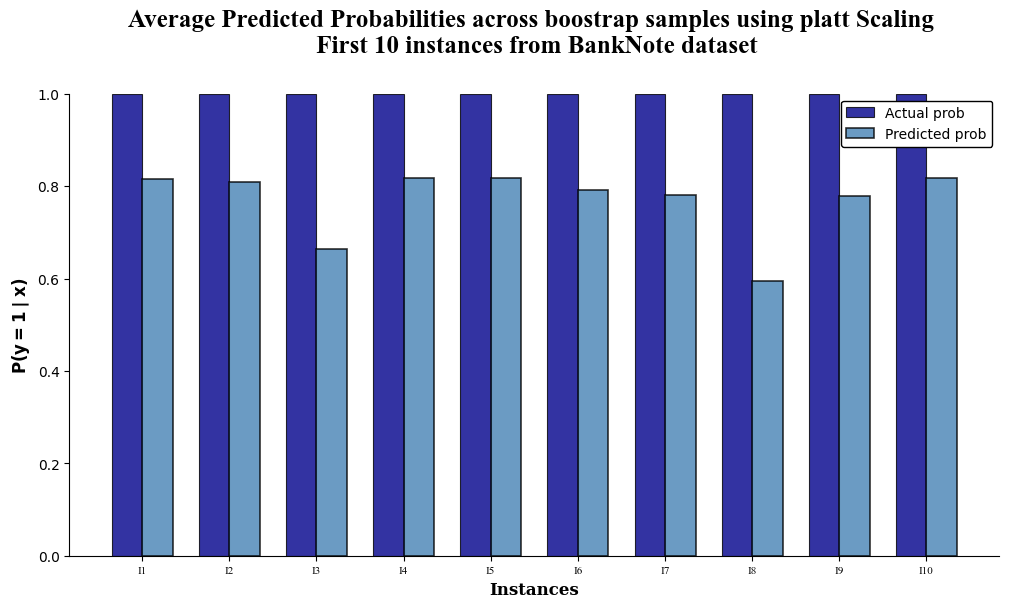

In [74]:
# Barplot representing actual vs avg predicted probability for the first 10 instances
n_obs = 10
x = np.arange(n_obs)
width = 0.35

# The two classes given at the target variable of every dataset are +1 and 0
actual_probs = Y.iloc[-n_obs:].values.ravel()

fig, ax = plt.subplots(figsize = (12,6))
ax.bar(x - width/2, actual_probs, width, label = 'Actual prob', color = 'darkblue', alpha = 0.8, edgecolor = 'black', linewidth = 0.8)
ax.bar(x + width/2, avg_predicted_probs[-n_obs:], width, label = 'Predicted prob', color = 'steelblue', alpha = 0.8, edgecolor = 'black', linewidth = 1.2)
ax.set_title(f'Average Predicted Probabilities across boostrap samples using {method} Scaling \n First {n_obs} instances from {dataset_name} dataset', pad = 30, fontdict = title_font)
ax.set_xlabel('Instances', fontdict= axes_font)
ax.set_xticks(x)
ax.set_xticklabels([f'I{i+1}' for i in range(n_obs)], fontdict = aux_font)
ax.set_ylabel(r'$\mathbf{P(y = 1 \mid x)}$', fontdict = axes_font)
ax.set_ylim(0,1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc = 'upper right', edgecolor = 'black', framealpha = 1)
plt.show()

### MSE Distribution across OOB sets for the optimal hyperparameter combinations

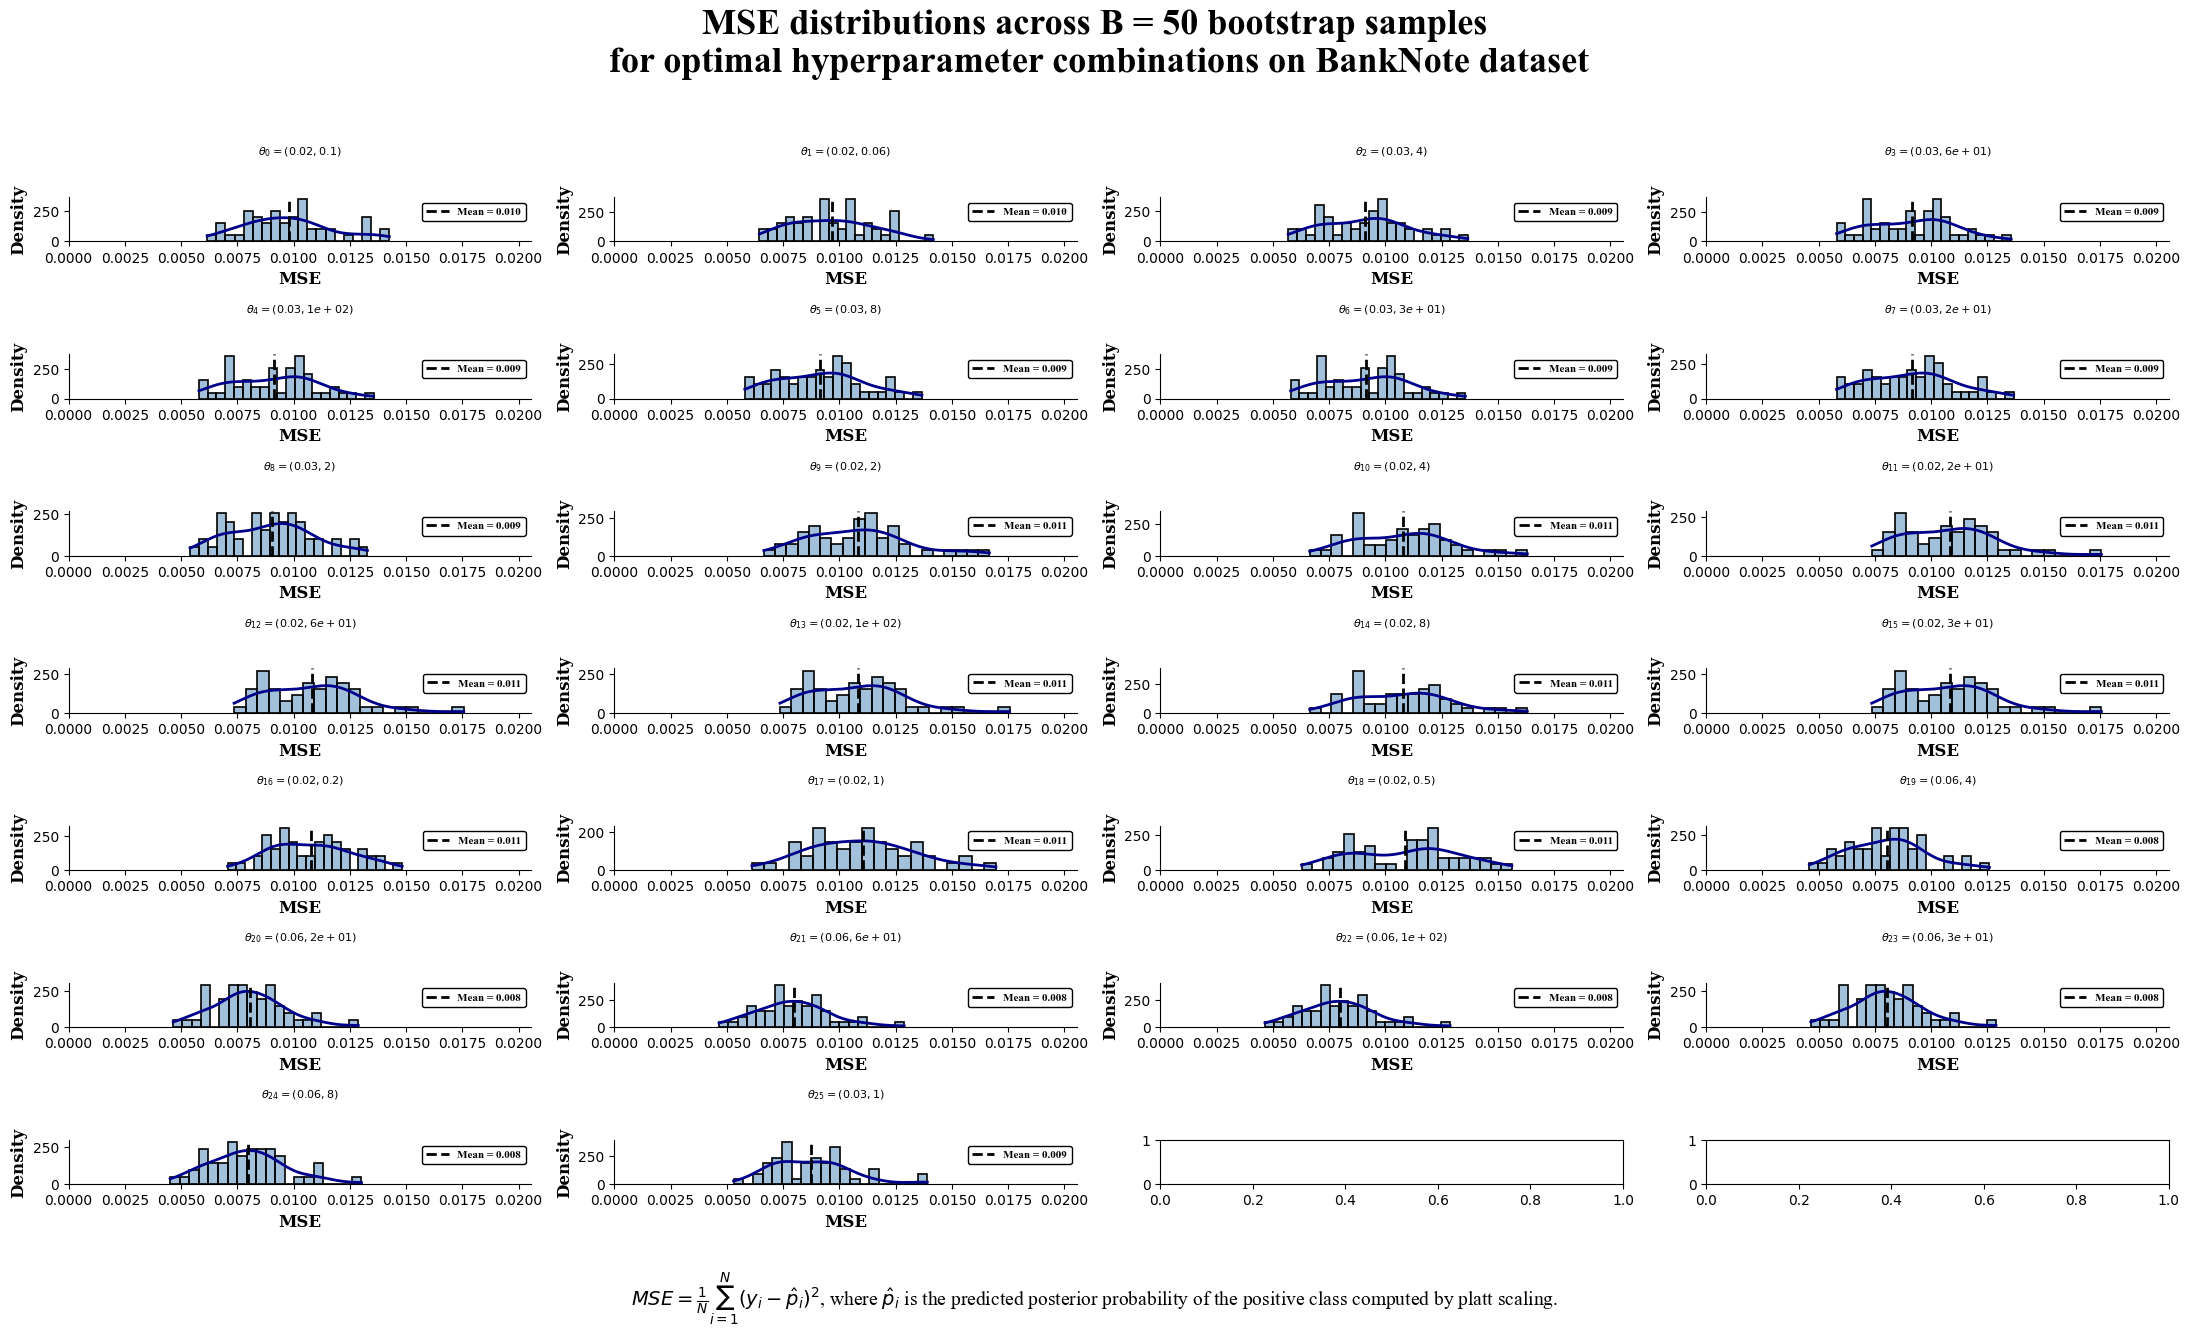

In [75]:
x_max = max(np.max(mse[theta]) for theta in top_theta)
x_min = min(np.min(mse[theta]) for theta in top_theta)

# Define number of rows and columns on the subplot layout
n_cols = min(4, len(top_theta))
n_rows = int(np.ceil(len(top_theta) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 12))

# Make axes always iterable as 1D
axes = np.array(axes).reshape(-1)

for t, theta in enumerate(top_theta):

    ax = axes[t]

    sns.histplot(mse[theta], bins=20, kde=True, stat='density', color='steelblue', edgecolor='black', linewidth= 1.2, ax=ax)
    ax.set_xlim(0.0, x_max + 0.003)# In binary classification, MSE is restricted to the range (0,1)
    ax.lines[-1].set_color('darkblue')
    ax.lines[-1].set_linewidth(2)
    ax.axvline(avg_mse[theta], linewidth = 2, color = 'black', linestyle = '--', label = f'Mean = {avg_mse[theta]:.3f}')
    theta_str = ', '.join(f'{float(v):.0g}' for v in theta)
    ax.set_title(rf'$\boldsymbol{{\theta_{{{t}}}}} = \left({theta_str}\right)$', fontdict=aux_font, pad=30)
    ax.set_xlabel('MSE', fontdict = axes_font)
    ax.set_ylabel('Density', fontdict = axes_font)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc = 'upper right', edgecolor = 'black', framealpha = 1, prop = {'size':8, 'weight': 'bold', 'family': 'Times New Roman'})

plt.suptitle(f'MSE distributions across B = {B} bootstrap samples\n for optimal hyperparameter combinations on {dataset_name} dataset',
             fontsize = 26, fontweight = 'bold', fontfamily = 'Times New Roman', y = 1.03)

plt.figtext(
    0.5, -0.05, rf"$MSE = \frac{{1}}{{N}}\sum_{{i=1}}^N (y_i - \hat{{p}}_i)^2$, "
    rf"where $\hat{{p}}_i$ is the predicted posterior probability "
    rf"of the positive class computed by {method} scaling.", ha='center', fontsize=14, fontfamily='Times New Roman'
)
plt.tight_layout()
plt.show()

### Feature Selection Heatmap hyperplane 1

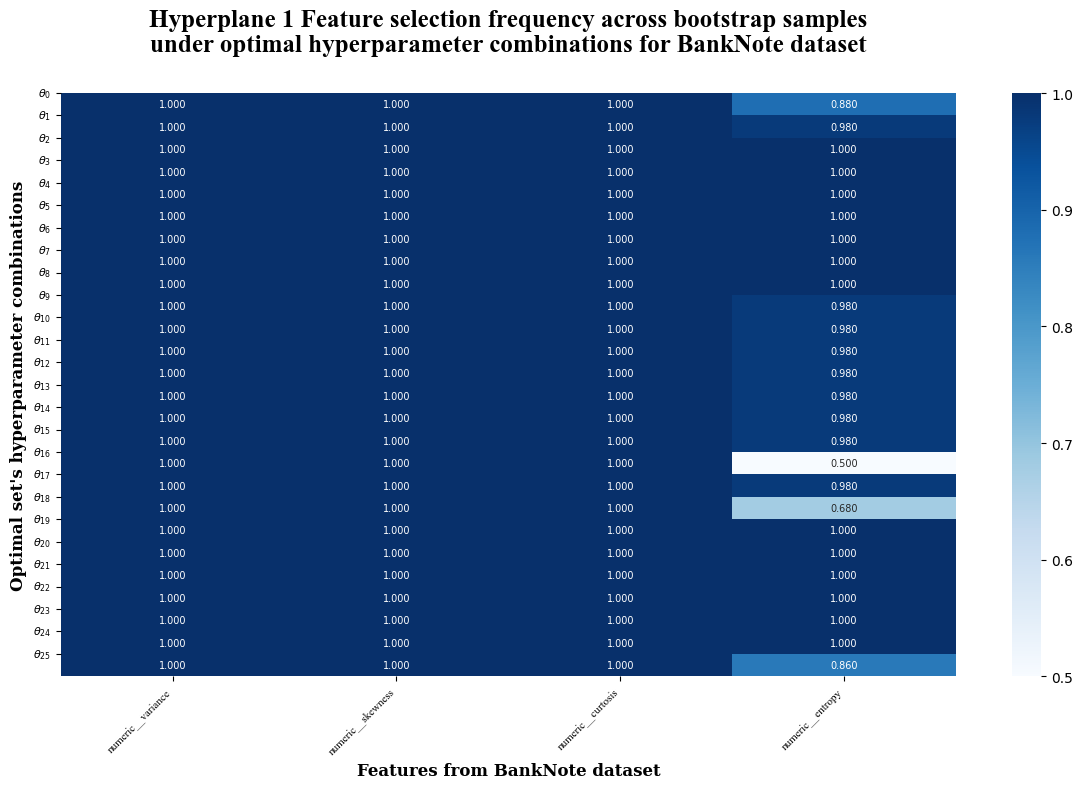

In [76]:
h1_fs_heatmap = np.zeros((len(top_theta), len(features_names)), dtype = int)

# Absolute frequence (counts) each feature was selected by hyperplane 1
for t, theta in enumerate(top_theta):
    for b in range(B):
        for feat_idx in selected_fs_n1[theta][b]:

            h1_fs_heatmap[t, feat_idx] += 1


# Proportion of bootstrap samples on which each feature was selected by hyperplane 1
h1_fs_heatmap = h1_fs_heatmap / B

# Hyperplane 1 feature selection Heatmap
fig_height = max(12, len(top_theta) * 0.3)
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(h1_fs_heatmap, cmap='Blues',
            annot=True, fmt='.3f', annot_kws={'size': 7}, ax=ax)
ax.set_title(f'Hyperplane 1 Feature selection frequency across bootstrap samples\n'
             f'under optimal hyperparameter combinations for {dataset_name} dataset',
             fontdict=title_font, pad = 30)
ax.set_xlabel(f'Features from {dataset_name} dataset', fontdict=axes_font)
ax.set_ylabel("Optimal set's hyperparameter combinations", fontdict=axes_font)
theta_labels = [
    rf'$\boldsymbol{{\theta_{{{t}}}}}$' for t, theta in enumerate(top_theta)
]
ax.set_xticklabels(features_names, fontdict=aux_font, rotation=45, ha='right')
ax.set_yticks(np.arange(len(theta_labels)))
ax.set_yticklabels(theta_labels, fontdict=aux_font, rotation=0)

plt.tight_layout()
plt.show()

### Feature Selection Heatmap hyperplane 2

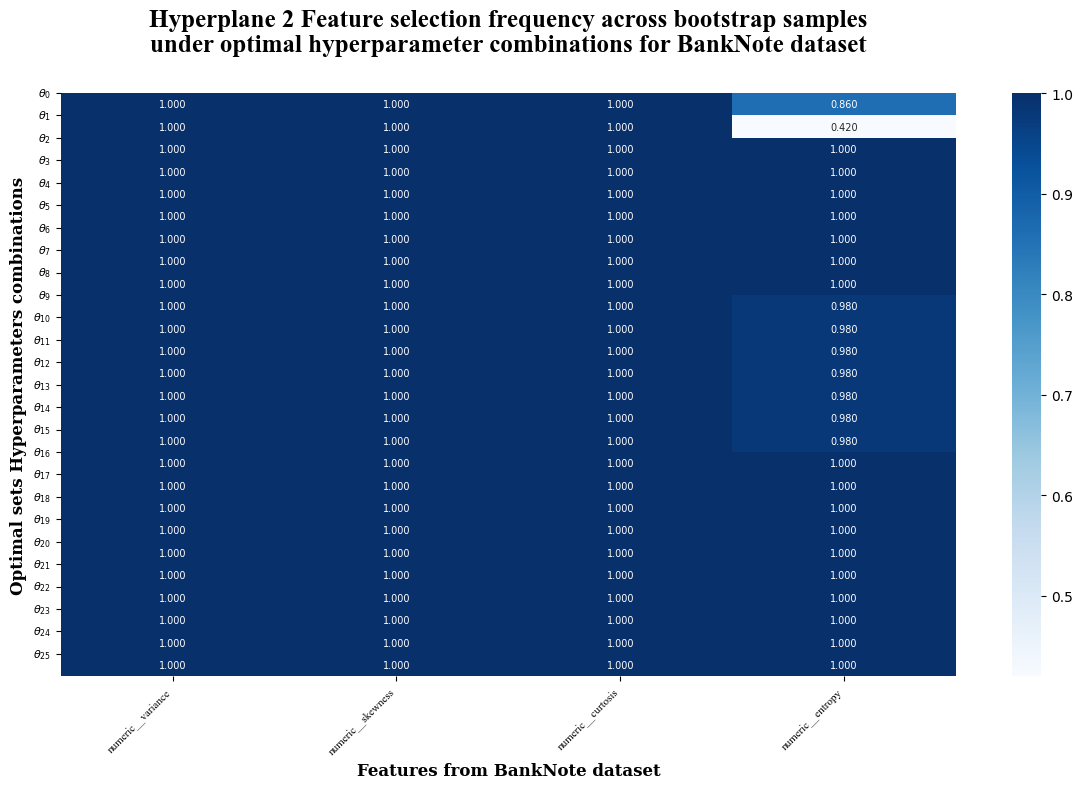

In [77]:
h2_fs_heatmap = np.zeros((len(top_theta), len(features_names)), dtype = float)

# Absolute frequence (counts) each feature was selected by hyperplane 2
for t, theta in enumerate(top_theta):
    for b in range(B):
        for feat_idx in selected_fs_n2[theta][b]:
            h2_fs_heatmap[t, feat_idx] += 1

# Proportion of bootstrap samples on which each feature was selected by hyperplane 2
h2_fs_heatmap = h2_fs_heatmap / B

fig, ax = plt.subplots(figsize = (12, 8))
sns.heatmap(h2_fs_heatmap, cmap = 'Blues', annot= True, fmt = '.3f',
            annot_kws={'size': 7}, ax=ax)
ax.set_title(f'Hyperplane 2 Feature selection frequency across bootstrap samples\n'
             f'under optimal hyperparameter combinations for {dataset_name} dataset', fontdict = title_font, pad = 30)
ax.set_xlabel(f'Features from {dataset_name} dataset', fontdict = axes_font)
ax.set_ylabel(f'Optimal sets Hyperparameters combinations', fontdict = axes_font)
theta_labels = [
    rf'$\boldsymbol{{\theta_{{{t}}}}}$' for t, theta in enumerate(top_theta)
]
ax.set_xticklabels(features_names, fontdict=aux_font, rotation=45, ha='right')
ax.set_yticks(np.arange(len(theta_labels)))
ax.set_yticklabels(theta_labels, fontdict=aux_font, rotation=0)

plt.tight_layout()
plt.show()

### Summary: Feature importance

In [78]:
# Compute the complete heatmaps matrices containing the absolute frequence 
# with which each feature was selected on each possible hyperparameter combination 
complete_h1_fs_heatmap = np.zeros((len(all_theta), len(features_names)), dtype = float)
for t, theta in enumerate(all_theta):
    for b in range(B):
        for feat_idx in selected_fs_n1[theta][b]:
            complete_h1_fs_heatmap[t, feat_idx] += 1

# Convert to relative frequence (proportion)
complete_h1_fs_heatmap /= B

complete_h2_fs_heatmap = np.zeros((len(all_theta), len(features_names)), dtype = float)
for t, theta in enumerate(all_theta):
    for b in range(B):
        for feat_idx in selected_fs_n2[theta][b]:
            complete_h2_fs_heatmap[t, feat_idx] += 1

complete_h2_fs_heatmap /= B

# Compute the importance of each feature given by each hyperplane as the sum
# of the products between the relative frequence with which each feature was selected by the hyperplane
# at each hyperparameters combinations times the weights of each hyperparameters combinations 
feature_importance_h1 = complete_h1_fs_heatmap.T @ mse_weights_std
feature_importance_h2 = complete_h2_fs_heatmap.T @ mse_weights_std

# Feature importance summary
feature_importance_h1_dict = {
    feature: feature_importance_h1[i]
    for i, feature in enumerate(features_names)
}

feature_importance_h2_dict = {
    feature: feature_importance_h2[i]
    for i, feature in enumerate(features_names)
}

sorted_h1 = sorted(
    feature_importance_h1_dict.items(),
    key=lambda x: x[1],
    reverse=True
)

sorted_h2 = sorted(
    feature_importance_h2_dict.items(),
    key=lambda x: x[1],
    reverse=True
)

print(f"{f'H1 selected {dataset_name} features':<38}{'H1 Feature importance':<21} {f'H2 selected {dataset_name} features':<38} {f'H2 Feature importance':<21}")
for (feat1, imp1), (feat2, imp2) in zip(sorted_h1, sorted_h2):
    print(f"{feat1:<38} {imp1:<21.4f} {feat2:<38} {imp2:<21.4f}")

H1 selected BankNote features         H1 Feature importance H2 selected BankNote features          H2 Feature importance
numeric__variance                      0.7006                numeric__variance                      0.6896               
numeric__skewness                      0.7006                numeric__skewness                      0.6896               
numeric__curtosis                      0.7000                numeric__curtosis                      0.6859               
numeric__entropy                       0.4928                numeric__entropy                       0.4889               


### Accuracy across Bootstrap samples Heatmap

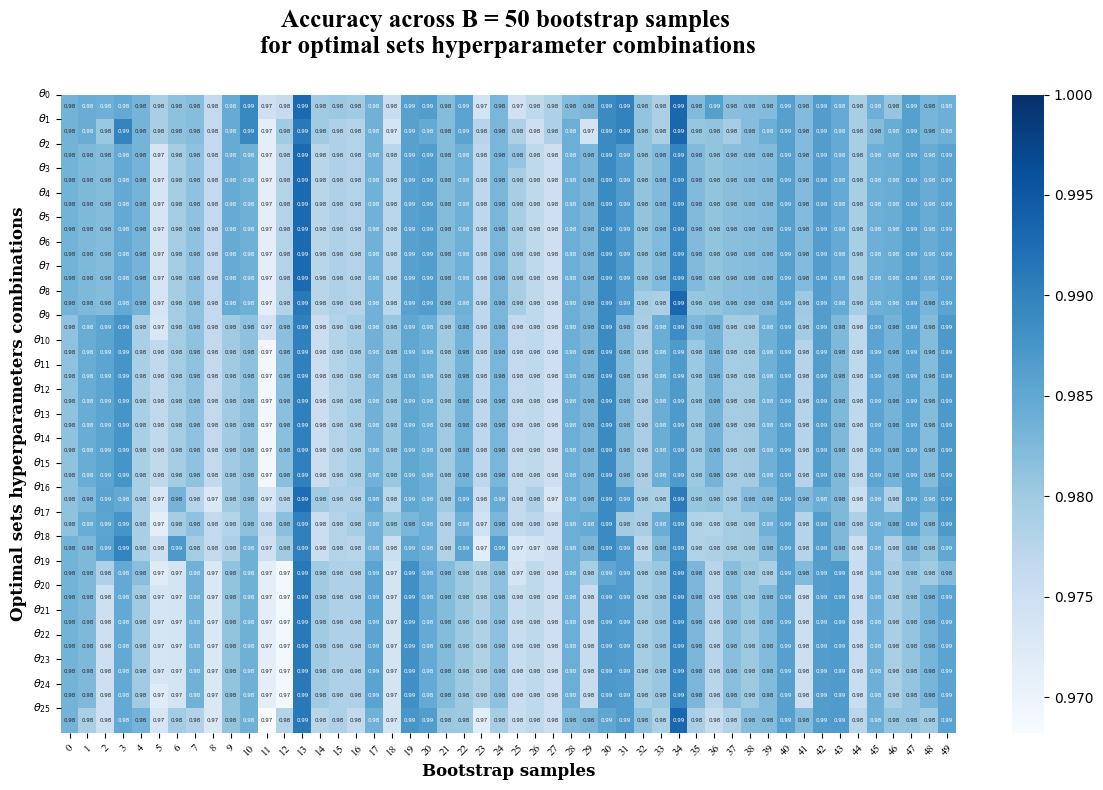

In [79]:
accuracy_heatmap = np.zeros((len(top_theta), B), dtype = float)

for t, theta in enumerate(top_theta):
    accuracy_heatmap[t,:] = accuracies[theta]

fig, axes = plt.subplots(figsize = (12,8))

sns.heatmap(accuracy_heatmap, cmap = 'Blues', fmt= '.2f', annot = True, vmax = 1.0,
            ax = axes, annot_kws={'size': 4})
axes.set_title(f'Accuracy across B = {B} bootstrap samples \n'
               'for optimal sets hyperparameter combinations', fontdict = title_font, pad = 30)
axes.set_xlabel('Bootstrap samples', fontdict = axes_font)
axes.set_ylabel('Optimal sets hyperparameters combinations', fontdict = axes_font)
axes.set_xticklabels(np.arange(B), fontdict = aux_font, rotation = 45)
theta_labels = [
    rf'$\boldsymbol{{\theta_{{{t}}}}}$' for t, theta in enumerate(top_theta)
]
axes.set_yticks(np.arange(len(top_theta)) + 0.5)
axes.set_yticks(np.arange(len(theta_labels)))
axes.set_yticklabels(theta_labels, fontdict=aux_font, rotation=0)

plt.tight_layout()
plt.show()

### MSE across Bootstrap samples Heatmap

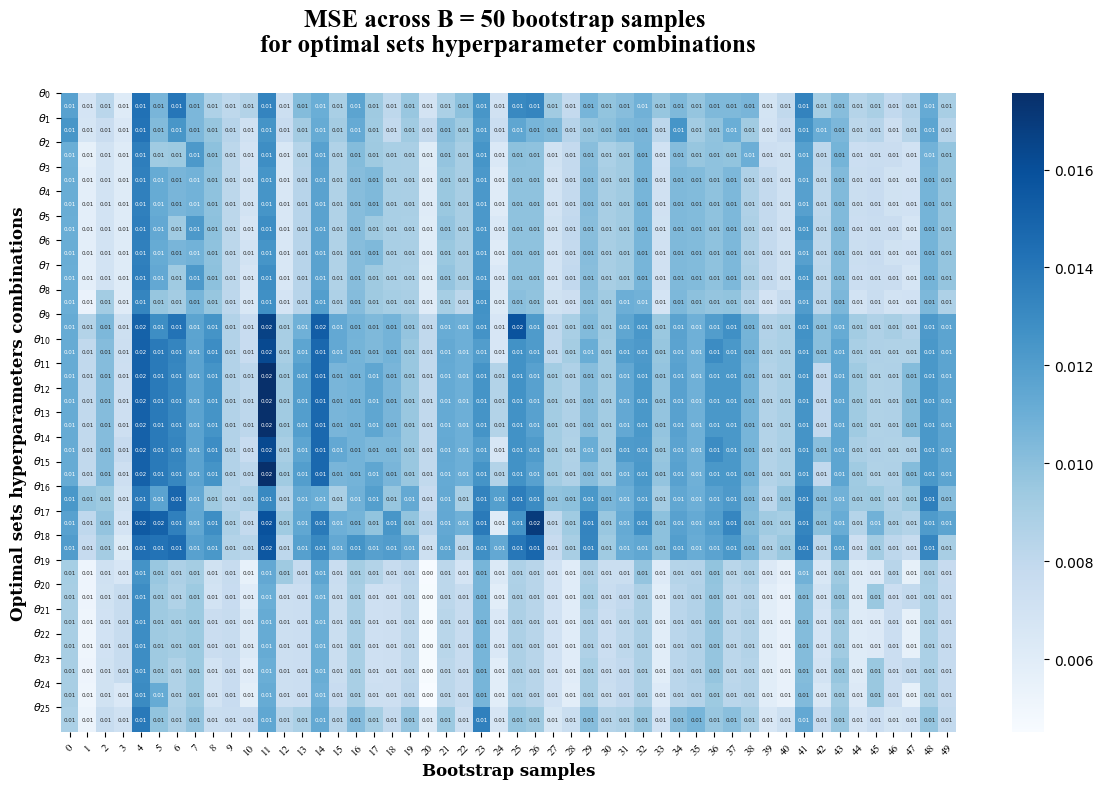

In [80]:
mse_heatmap = np.zeros((len(top_theta), B), dtype = float)

for t, theta in enumerate(top_theta):
    mse_heatmap[t,:] = mse[theta]

fig, axes = plt.subplots(figsize = (12,8))

sns.heatmap(mse_heatmap, cmap = 'Blues', fmt= '.2f', annot = True,
            ax = axes, annot_kws = {'size':4})
axes.set_title(f'MSE across B = {B} bootstrap samples \n'
               'for optimal sets hyperparameter combinations', fontdict = title_font, pad = 30)
axes.set_xlabel('Bootstrap samples', fontdict = axes_font)
axes.set_ylabel('Optimal sets hyperparameters combinations', fontdict = axes_font)
axes.set_xticklabels(np.arange(B), fontdict = aux_font, rotation = 45)
theta_labels = [
    rf'$\boldsymbol{{\theta_{{{t}}}}}$' for t, theta in enumerate(top_theta)
]
axes.set_yticks(np.arange(len(top_theta)) + 0.5)
axes.set_yticks(np.arange(len(theta_labels)))
axes.set_yticklabels(theta_labels, fontdict=aux_font, rotation=0)

plt.tight_layout()
plt.show()

# Post- hoc Joint feature selection

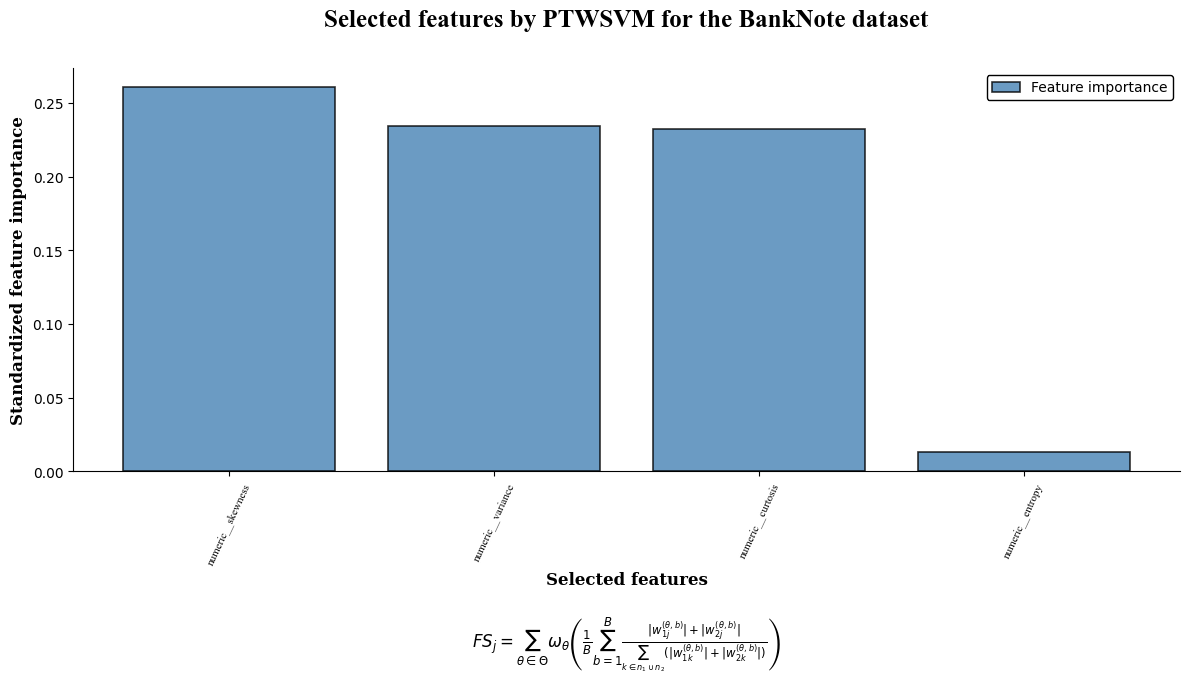

In [81]:
# Compute the average score for each feature across bootstrap samples for every given theta
avg_joint_fs_score = np.zeros((len(all_theta), len(features_names)), dtype = float)

for t, theta in enumerate(all_theta):
    for b in range(B):
        fs_indices = selected_fs[theta][b]
        fs_scores = joint_fs_score[theta][b]

        for fs_idx, fs_score in zip(fs_indices, fs_scores):
            avg_joint_fs_score[t, fs_idx] += fs_score
    avg_joint_fs_score[t] /= B

# Weight the average feature importance of each feature at every given theta
# by the standarize average mse scored by each theta  
post_hoc_joint_fs = avg_joint_fs_score.T @ mse_weights_std

# Sort features by decreasing importance
post_hoc_joint_fs_idx = np.argsort(post_hoc_joint_fs)[::-1]
post_hoc_joint_fs = post_hoc_joint_fs[post_hoc_joint_fs_idx]

fig, ax = plt.subplots(figsize = (12,8))
ax.bar(features_names[post_hoc_joint_fs_idx], post_hoc_joint_fs, color = 'steelblue', alpha = 0.8, label = 'Feature importance', edgecolor = 'black', linewidth = 1.2)

ax.set_title(f'Selected features by PTWSVM for the {dataset_name} dataset', pad = 30, fontdict= title_font)
ax.set_xticks(np.arange(len(features_names[post_hoc_joint_fs_idx])))
ax.set_xticklabels(features_names[post_hoc_joint_fs_idx], rotation = 65, fontdict = aux_font)
ax.set_xlabel(f'Selected features', fontdict = axes_font)
ax.set_ylabel(r'Standardized feature importance', fontdict=axes_font)
ax.legend(loc='upper right', prop={'size': 10}, edgecolor = 'black', framealpha = 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate(    r'$FS_j = \sum_{\theta \in \Theta}\omega_\theta' r'\left(' r'\frac{1}{B}\sum_{b=1}^{B}' 
            r'\frac{|w_{1j}^{(\theta,b)}| + |w_{2j}^{(\theta,b)}|}' r'{\sum_{k \in n_1 \cup n_2}'
            r'(|w_{1k}^{(\theta,b)}| + |w_{2k}^{(\theta,b)}|)}' r'\right)$',
            xy=(.5, -.5), xycoords='axes fraction', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

# PTWSVM on the two most informative features

PTWSVM define the hyperplanes as, 
$$
{w^{(i)}}^Tx+b^{(i)} \forall i = 1,2
$$
Restricting the original dataset to the two most relevant features according the earlier post- hoc joint feature selection,
$$
w_i = \begin{bmatrix} w_1^{(i)} \\ w_2^{(i)}\end{bmatrix} \forall i = 1,2\,\,\text{and}\,\, x = \begin{bmatrix} x_1 \\ x_2\end{bmatrix}
$$ 
Then, the decision boundary projected by the PTWSVM becomes, 
$$
x_2 = - \frac{w_1^{(i)}}{w_2^{(i)}}x_1 - \frac{b^{(i)}}{w_2^{(i)}} \forall i = 1,2
$$

In [82]:
# Two most relevant features observed earlier
most_relevant_features = post_hoc_joint_fs_idx[:2]

# Initialize new preprocessor for X_reduced
X_processed = preprocessor.fit_transform(X)  # Apply preprocessing to X_reduced
X_reduced = X_processed[:,most_relevant_features]
# Once applied the preprocessing the resulting obj is numpy array
Y_reduced = Y.values.ravel() # convert original Y df into 1d numpy array 

reduced_A = X_reduced[Y_reduced == 1]
reduced_B = X_reduced[Y_reduced == 0]

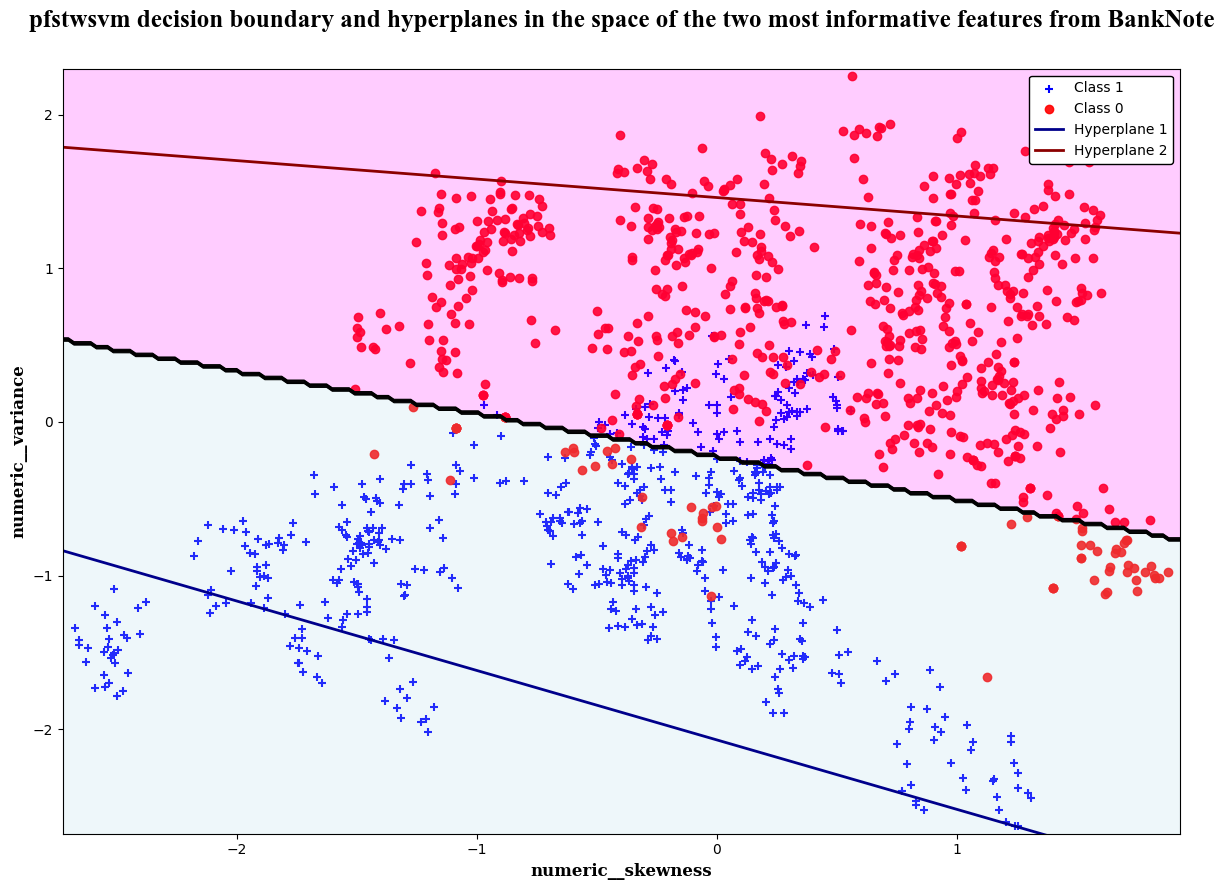

In [83]:
from matplotlib.colors import ListedColormap

# pfstwsvm instance using the optimal hyperparameter combination
best_params = top_theta[0]

pfstwsvm = PFSTWSVM(best_params[0], best_params[0], best_params[1], best_params[1])
# Fit pfstwsvm on the reduced version of the entire dfs X, Y
pfstwsvm.fit(X_reduced, Y_reduced)

# Meshgrid for representing the decision boundary
h = 200
x_min, x_max = X_reduced[:, 0].min() - 0.05, X_reduced[:, 0].max() + 0.05
y_min, y_max = X_reduced[:, 1].min() - 0.05, X_reduced[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, h),
                     np.linspace(y_min, y_max, h))

zz = pfstwsvm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Grid for evaluating the hyperplanes
xgrid = np.linspace(x_min, x_max, 100)

# Retrieve opt parameters for hyperplanes representation
w1 = pfstwsvm.w1_
w2 = pfstwsvm.w2_
b1 = pfstwsvm.b1_
b2 = pfstwsvm.b2_

# Compute hyperplanes
def plot_hyperplane(ax, w, b, xgrid, **kwargs):
    if abs(w[1]) > 1e-12:
        # Horizontal hyperplane (solve for the value of x2)
        x2 = -(w[0] / w[1]) * xgrid - (b / w[1])
        ax.plot(xgrid, x2, **kwargs)
    elif abs(w[0]) > 1e-12:
        # Vertical hyperplane (solve for the value of x1)
        x1 = -b / w[0]
        ax.axvline(x = x1, **kwargs)
    else:
        print('There is a degenerated hyperplane with both of its weights been collapsed to zero')


# Decision boundary and hyperplanes of the pfstwsvm model
# retrained exclusively on the two most informative features identified by feature selection
class_map = ListedColormap(['magenta', 'lightblue'])

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(reduced_A[:, 0], reduced_A[:, 1], marker='+', color='blue', label='Class 1', alpha=1.0)
ax.scatter(reduced_B[:, 0], reduced_B[:, 1], marker='o', color='red',  label='Class 0', alpha=0.9)
plot_hyperplane(ax, w1, b1, xgrid, color='darkblue', label='Hyperplane 1', linewidth=2)
plot_hyperplane(ax, w2, b2, xgrid, color='darkred',  label='Hyperplane 2', linewidth=2)
ax.contourf(xx, yy, zz, alpha=0.2, cmap= class_map)
ax.contour(xx, yy, zz, colors='black', linewidths=0.8)
ax.set_title(f'pfstwsvm decision boundary and hyperplanes in the space of the two most informative features from {dataset_name}', pad = 30, fontdict = title_font)
ax.set_xlabel(f'{features_names[most_relevant_features[0]]}', fontdict = axes_font)
ax.set_ylabel(f'{features_names[most_relevant_features[1]]}', fontdict = axes_font)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.legend(loc='upper right', prop = {'size': 10}, edgecolor = 'black', framealpha = 1)
plt.tight_layout()
plt.show()